# 📊 Financial Loan Portfolio Analysis
## Hero FinCorp — Complete Analysis Report (Tasks 1–9)

| Dataset | Description |
|---------|-------------|
| `customers.csv` | Customer demographics and profile |
| `loans.csv` | Loan-level information |
| `transactions.csv` | Payment transaction records |
| `defaults.csv` | Loan default records |
| `applications.csv` | Loan application details |
| `branches.csv` | Branch-level performance |

---

## 🔧 Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


## 📂 Load Raw Datasets

In [2]:
DATA_DIR = 'c:/Users/DELL/Desktop/Ranjita mam/dataset'

customers    = pd.read_csv(f'{DATA_DIR}/customers.csv',    low_memory=False)
loans        = pd.read_csv(f'{DATA_DIR}/loans.csv',        low_memory=False)
transactions = pd.read_csv(f'{DATA_DIR}/transactions.csv', low_memory=False)
defaults     = pd.read_csv(f'{DATA_DIR}/defaults.csv',     low_memory=False)
applications = pd.read_csv(f'{DATA_DIR}/applications.csv', low_memory=False)
branches     = pd.read_csv(f'{DATA_DIR}/branches.csv',     low_memory=False)

datasets_raw = {
    'customers': customers, 'loans': loans, 'transactions': transactions,
    'defaults': defaults, 'applications': applications, 'branches': branches
}

print(f'{"Dataset":15s}  {"Rows":>8}  {"Cols":>5}')
print('-' * 35)
for name, df in datasets_raw.items():
    print(f'{name:15s}  {df.shape[0]:>8,}  {df.shape[1]:>5}')
print('\n✅ All datasets loaded.')

Dataset              Rows   Cols
-----------------------------------
customers          70,000     14
loans              90,000     12
transactions      495,000      9
defaults            9,000      9
applications       82,600     10
branches               50      9

✅ All datasets loaded.


---
# 🧹 Task 1: Data Quality and Preparation

> **Objectives**
> - Validate and clean all datasets
> - Check for missing values, duplicate entries, and inconsistent data
> - Standardize date formats and remove irrelevant columns
> - Handle outliers in numeric columns using IQR capping

---
## 1.1 Missing Value Analysis

In [3]:
def missing_report(name, df):
    miss = df.isnull().sum()
    pct  = miss / len(df) * 100
    rpt  = pd.DataFrame({'Missing_Count': miss, 'Missing_%': pct.round(2)})
    rpt  = rpt[rpt['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)
    print(f'\n[{name.upper()}]')
    if rpt.empty:
        print('  ✅ No missing values found.')
    else:
        print(rpt.to_string())
    return rpt

for name, df in datasets_raw.items():
    missing_report(name, df)


[CUSTOMERS]
  ✅ No missing values found.

[LOANS]
                    Missing_Count  Missing_%
Collateral_Details          30194      33.55

[TRANSACTIONS]
  ✅ No missing values found.

[DEFAULTS]
                 Missing_Count  Missing_%
Recovery_Status           2985      33.17

[APPLICATIONS]
                  Missing_Count  Missing_%
Rejection_Reason          70000      84.75
Loan_ID                   12600      15.25
Approval_Date             12600      15.25

[BRANCHES]
  ✅ No missing values found.


## 1.2 Missing Value Heatmaps

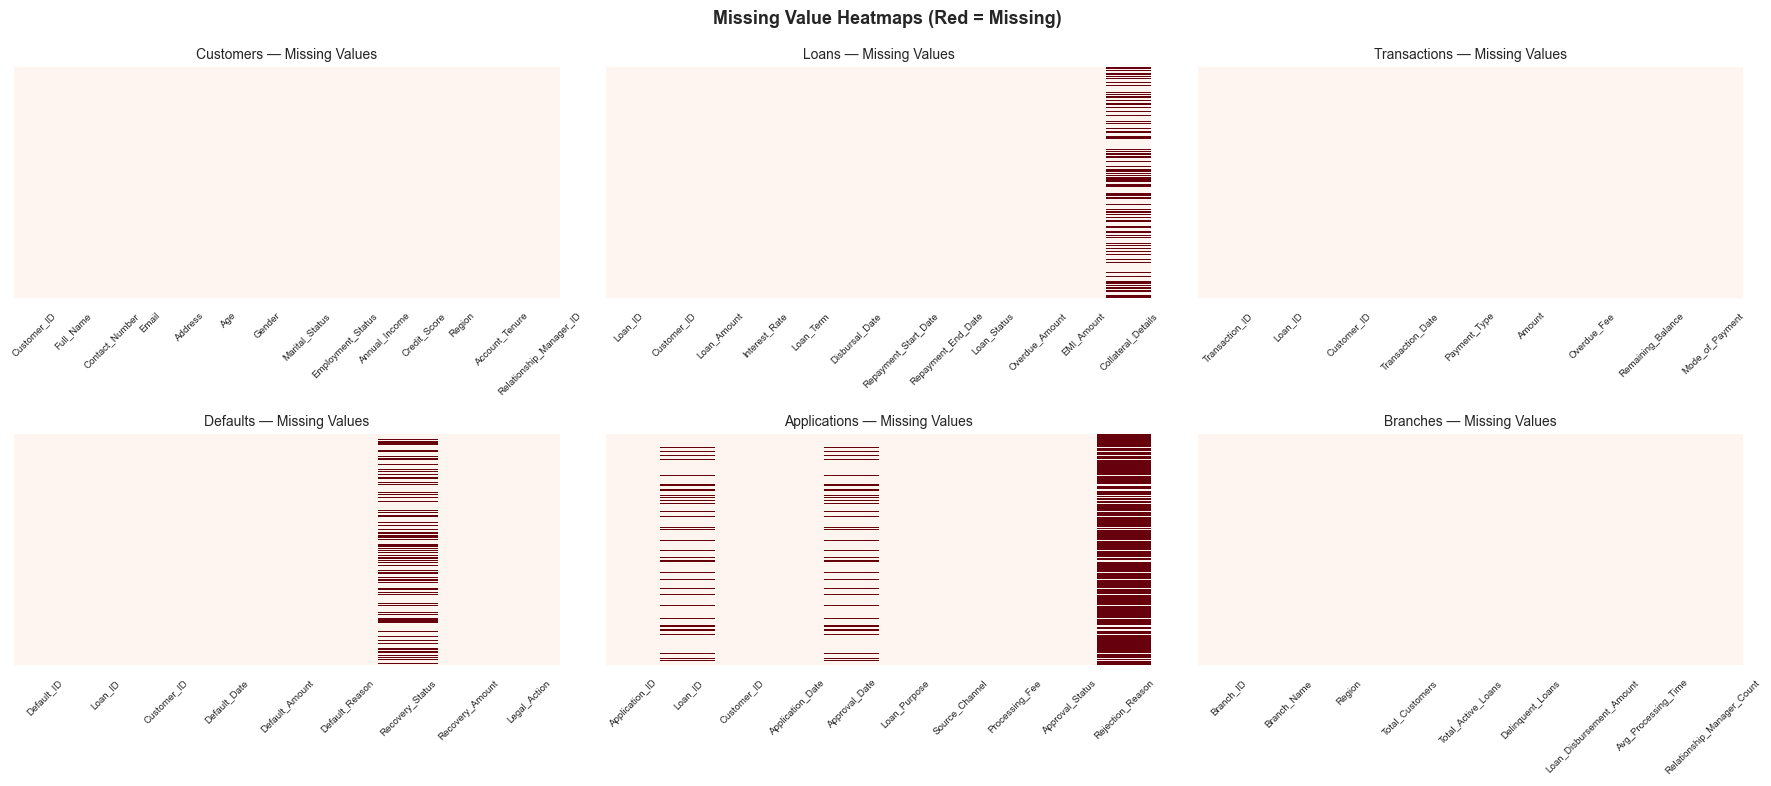

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, (name, df) in zip(axes.flatten(), datasets_raw.items()):
    sample = df.sample(min(300, len(df)), random_state=42)
    sns.heatmap(sample.isnull(), ax=ax, cbar=False, yticklabels=False, cmap='Reds')
    ax.set_title(f'{name.capitalize()} — Missing Values', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.suptitle('Missing Value Heatmaps (Red = Missing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.3 Duplicate Entry Check

In [5]:
print('Full-row duplicate check:')
for name, df in datasets_raw.items():
    d = df.duplicated().sum()
    icon = '✅' if d == 0 else '⚠️ '
    print(f'  {icon} {name:15s}: {d:,} duplicate rows')

pk_map = {
    'customers': 'Customer_ID', 'loans': 'Loan_ID',
    'transactions': 'Transaction_ID', 'defaults': 'Default_ID',
    'applications': 'Application_ID', 'branches': 'Branch_ID'
}
print('\nPrimary-key uniqueness check:')
for name, col in pk_map.items():
    d = datasets_raw[name][col].duplicated().sum()
    icon = '✅' if d == 0 else '⚠️ '
    print(f'  {icon} {name:15s} [{col}]: {d:,} duplicates')

Full-row duplicate check:
  ✅ customers      : 0 duplicate rows
  ✅ loans          : 0 duplicate rows
  ✅ transactions   : 0 duplicate rows
  ✅ defaults       : 0 duplicate rows
  ✅ applications   : 0 duplicate rows
  ✅ branches       : 0 duplicate rows

Primary-key uniqueness check:
  ✅ customers       [Customer_ID]: 0 duplicates
  ✅ loans           [Loan_ID]: 0 duplicates
  ✅ transactions    [Transaction_ID]: 0 duplicates
  ✅ defaults        [Default_ID]: 0 duplicates
  ✅ applications    [Application_ID]: 0 duplicates
  ✅ branches        [Branch_ID]: 0 duplicates


## 1.4 Data Cleaning — All Datasets

In [6]:
# ── CUSTOMERS ─────────────────────────────────────────────────────────────────
cust = customers.copy().drop_duplicates()
# Remove PII columns that are not analytically useful
drop_cols = [c for c in ['Address', 'Contact_Number', 'Email'] if c in cust.columns]
cust.drop(columns=drop_cols, inplace=True)
# Extract numeric year from Account_Tenure (e.g., '10 Years' → 10)
if 'Account_Tenure' in cust.columns:
    cust['Account_Tenure_Years'] = cust['Account_Tenure'].astype(str).str.extract(r'(\d+)').astype(float)
    cust.drop(columns=['Account_Tenure'], inplace=True)
# Fill missing values
for col in ['Gender', 'Marital_Status', 'Employment_Status', 'Region']:
    if col in cust.columns:
        cust[col].fillna('Unknown', inplace=True)
for col in ['Age', 'Annual_Income', 'Credit_Score']:
    if col in cust.columns:
        cust[col].fillna(cust[col].median(), inplace=True)
# Standardise casing
cust['Gender'] = cust['Gender'].str.strip().str.title()
print(f'✅ customers cleaned  → {cust.shape}')

# ── LOANS ──────────────────────────────────────────────────────────────────────
loan = loans.copy().drop_duplicates()
for col in ['Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date']:
    loan[col] = pd.to_datetime(loan[col], errors='coerce')
loan['Overdue_Amount'].fillna(0, inplace=True)
loan['EMI_Amount'].fillna(loan['EMI_Amount'].median(), inplace=True)
if 'Collateral_Details' in loan.columns:
    loan['Collateral_Details'].fillna('None', inplace=True)
loan['Loan_Status'] = loan['Loan_Status'].str.strip().str.title()
print(f'✅ loans cleaned      → {loan.shape}')

# ── TRANSACTIONS ───────────────────────────────────────────────────────────────
txn = transactions.copy().drop_duplicates()
txn['Transaction_Date'] = pd.to_datetime(txn['Transaction_Date'], errors='coerce')
txn['Overdue_Fee'].fillna(0, inplace=True)
txn['Mode_of_Payment'].fillna('Unknown', inplace=True)
txn['Payment_Type']    = txn['Payment_Type'].str.strip().str.title()
txn['Mode_of_Payment'] = txn['Mode_of_Payment'].str.strip().str.upper()
print(f'✅ transactions cleaned → {txn.shape}')

# ── DEFAULTS ───────────────────────────────────────────────────────────────────
defs = defaults.copy().drop_duplicates()
defs['Default_Date'] = pd.to_datetime(defs['Default_Date'], errors='coerce')
defs['Recovery_Amount'].fillna(0, inplace=True)
for col in ['Default_Reason', 'Recovery_Status', 'Legal_Action']:
    defs[col].fillna('Unknown', inplace=True)
    defs[col] = defs[col].str.strip().str.title()
print(f'✅ defaults cleaned   → {defs.shape}')

# ── APPLICATIONS ───────────────────────────────────────────────────────────────
apps = applications.copy().drop_duplicates()
apps['Application_Date'] = pd.to_datetime(apps['Application_Date'], errors='coerce')
apps['Approval_Date']    = pd.to_datetime(apps['Approval_Date'],    errors='coerce')
apps['Processing_Fee'].fillna(apps['Processing_Fee'].median(), inplace=True)
apps['Approval_Status'] = apps['Approval_Status'].str.strip().str.title()
apps['Source_Channel']  = apps['Source_Channel'].str.strip().str.title()
apps['Loan_Purpose']    = apps['Loan_Purpose'].str.strip().str.title()
apps['Rejection_Reason'] = apps.apply(
    lambda r: 'N/A' if r['Approval_Status'] == 'Approved'
              else (r['Rejection_Reason'] if pd.notna(r['Rejection_Reason']) else 'Unknown'),
    axis=1
)
print(f'✅ applications cleaned → {apps.shape}')

# ── BRANCHES ───────────────────────────────────────────────────────────────────
branch = branches.copy().drop_duplicates()
branch['Region'] = branch['Region'].str.strip().str.title()
for col in ['Total_Customers', 'Total_Active_Loans', 'Delinquent_Loans',
            'Loan_Disbursement_Amount', 'Avg_Processing_Time', 'Relationship_Manager_Count']:
    if col in branch.columns:
        branch[col].fillna(branch[col].median(), inplace=True)
print(f'✅ branches cleaned  → {branch.shape}')

✅ customers cleaned  → (70000, 11)
✅ loans cleaned      → (90000, 12)
✅ transactions cleaned → (495000, 9)
✅ defaults cleaned   → (9000, 9)
✅ applications cleaned → (82600, 10)
✅ branches cleaned  → (50, 9)


## 1.5 Outlier Detection & Handling (IQR Winsorization)

In [7]:
def cap_iqr(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = int(((df[col] < lo) | (df[col] > hi)).sum())
    df[col] = df[col].clip(lo, hi)
    print(f'  {col:>30s}: {n_out:>5,} outliers capped  [{lo:>12,.0f} → {hi:>12,.0f}]')
    return df

print('=== LOANS ===')
for c in ['Loan_Amount', 'Interest_Rate', 'Overdue_Amount', 'EMI_Amount']:
    loan = cap_iqr(loan, c)
print('\n=== DEFAULTS ===')
for c in ['Default_Amount', 'Recovery_Amount']:
    defs = cap_iqr(defs, c)
print('\n=== CUSTOMERS ===')
for c in ['Age', 'Annual_Income', 'Credit_Score']:
    cust = cap_iqr(cust, c)
print('\n=== TRANSACTIONS ===')
for c in ['Amount', 'Overdue_Fee', 'Remaining_Balance']:
    txn = cap_iqr(txn, c)
print('\n✅ Outlier capping complete.')

=== LOANS ===
                     Loan_Amount:     0 outliers capped  [  -2,438,291 →    7,465,697]
                   Interest_Rate:     0 outliers capped  [           3 →           19]
                  Overdue_Amount:     0 outliers capped  [     -38,150 →       63,582]
                      EMI_Amount:     0 outliers capped  [     -47,572 →      149,234]

=== DEFAULTS ===
                  Default_Amount:     0 outliers capped  [     -41,802 →      148,300]
                 Recovery_Amount:     0 outliers capped  [     -38,224 →       63,708]

=== CUSTOMERS ===
                             Age:     0 outliers capped  [          -8 →           96]
                   Annual_Income:     0 outliers capped  [    -699,630 →    2,899,996]
                    Credit_Score:     0 outliers capped  [          23 →        1,127]

=== TRANSACTIONS ===
                          Amount:     0 outliers capped  [     -23,395 →       74,405]
                     Overdue_Fee:     0 outliers capped  

## 1.6 Outlier Visualisation (After Capping)

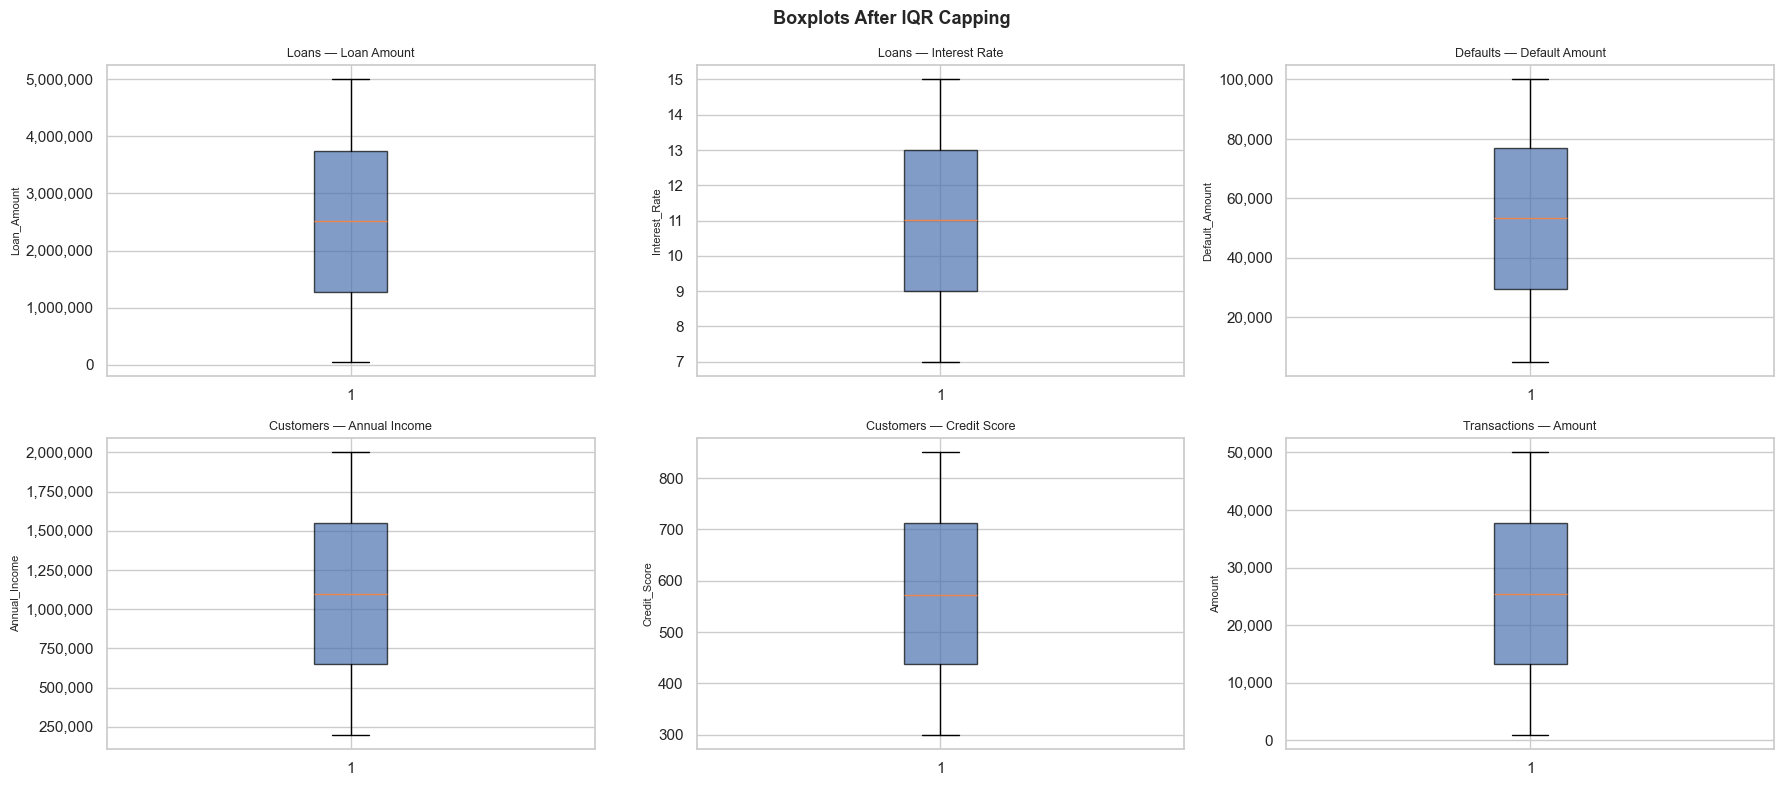

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
plot_data = [
    (loan, 'Loan_Amount',    'Loans — Loan Amount'),
    (loan, 'Interest_Rate',  'Loans — Interest Rate'),
    (defs, 'Default_Amount', 'Defaults — Default Amount'),
    (cust, 'Annual_Income',  'Customers — Annual Income'),
    (cust, 'Credit_Score',   'Customers — Credit Score'),
    (txn,  'Amount',         'Transactions — Amount'),
]
for ax, (df, col, title) in zip(axes.flatten(), plot_data):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7), showfliers=False)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel(col, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.suptitle('Boxplots After IQR Capping', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.7 Post-Cleaning Summary

In [9]:
# Add Default_Flag to loans (1 = defaulted)
defaulted_ids = set(defs['Loan_ID'])
loan['Default_Flag'] = loan['Loan_ID'].isin(defaulted_ids).astype(int)

cleaned_sets = [('customers', cust), ('loans', loan), ('transactions', txn),
                ('defaults', defs), ('applications', apps), ('branches', branch)]

print(f'{"Dataset":15s}  {"Rows":>8}  {"Cols":>5}  {"Missing":>8}  {"Dups":>6}')
print('─' * 50)
for name, df in cleaned_sets:
    print(f'{name:15s}  {df.shape[0]:>8,}  {df.shape[1]:>5}  '
          f'{df.isnull().sum().sum():>8,}  {df.duplicated().sum():>6,}')

total_def = loan['Default_Flag'].sum()
print(f'\nDefault_Flag: {total_def:,} defaulted loans out of {len(loan):,} '
      f'({total_def/len(loan)*100:.1f}%)')

Dataset              Rows   Cols   Missing    Dups
──────────────────────────────────────────────────
customers          70,000     11         0       0
loans              90,000     13         0       0
transactions      495,000      9         0       0
defaults            9,000      9         0       0
applications       82,600     10    25,200       0
branches               50      9         0       0

Default_Flag: 8,539 defaulted loans out of 90,000 (9.5%)


---
# 📈 Task 2: Descriptive Analysis

> **Objectives**
> - Distribution of Loan_Amount, EMI_Amount, and Credit_Score
> - Regional trends in loan disbursement and defaults
> - Monthly trends in loan approvals and disbursements

---
## 2.1 Distribution of Key Numeric Variables

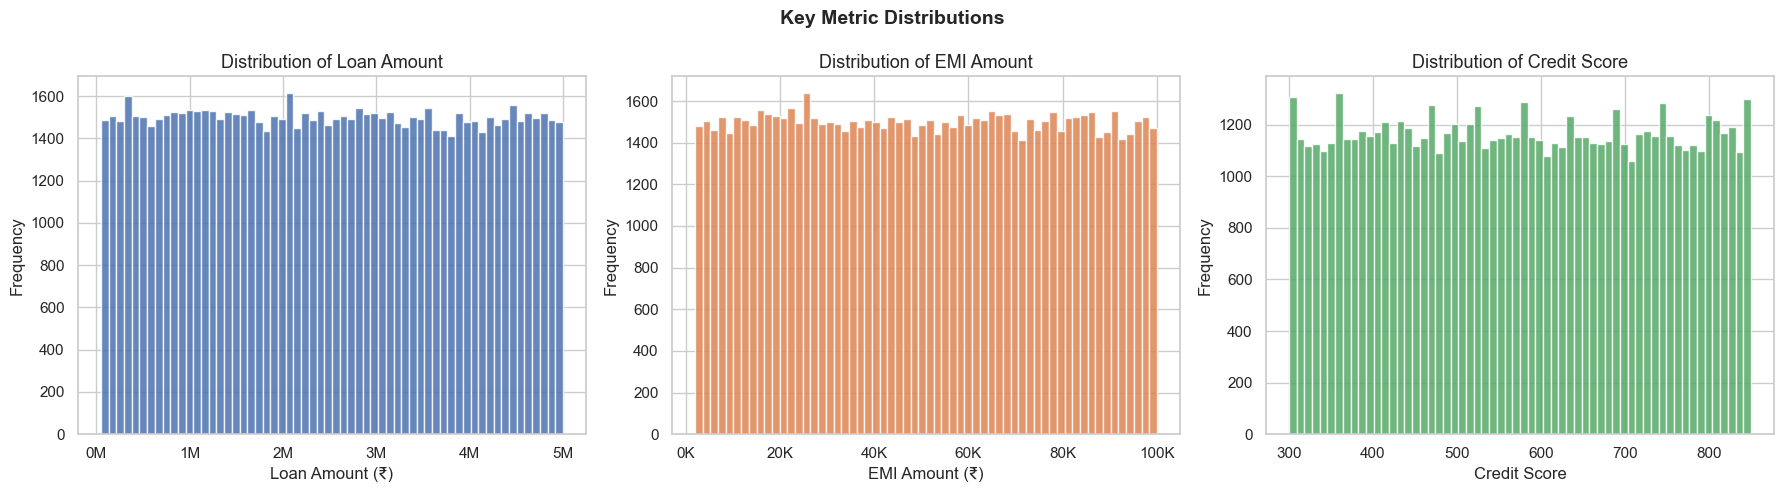

Loan Amount Stats:
count     90000.00
mean    2516259.00
std     1429289.00
min       50026.00
25%     1275705.00
50%     2510076.00
75%     3751702.00
max     4999958.00

EMI Amount Stats:
count    90000.00
mean     50874.00
std      28274.00
min       2001.00
25%      26230.00
50%      50861.00
75%      75431.00
max     100000.00

Credit Score Stats:
count   70000.00
mean      575.00
std       159.00
min       300.00
25%       437.00
50%       573.00
75%       713.00
max       850.00


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(loan['Loan_Amount'].dropna(), bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Loan Amount')
axes[0].set_xlabel('Loan Amount (₹)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

axes[1].hist(loan['EMI_Amount'].dropna(), bins=60, color='#DD8452', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of EMI Amount')
axes[1].set_xlabel('EMI Amount (₹)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

axes[2].hist(cust['Credit_Score'].dropna(), bins=60, color='#55A868', edgecolor='white', alpha=0.85)
axes[2].set_title('Distribution of Credit Score')
axes[2].set_xlabel('Credit Score')
axes[2].set_ylabel('Frequency')

plt.suptitle('Key Metric Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Loan Amount Stats:')
print(loan['Loan_Amount'].describe().round(0).to_string())
print('\nEMI Amount Stats:')
print(loan['EMI_Amount'].describe().round(0).to_string())
print('\nCredit Score Stats:')
print(cust['Credit_Score'].describe().round(0).to_string())

## 2.2 Regional Trends in Loan Disbursement and Defaults

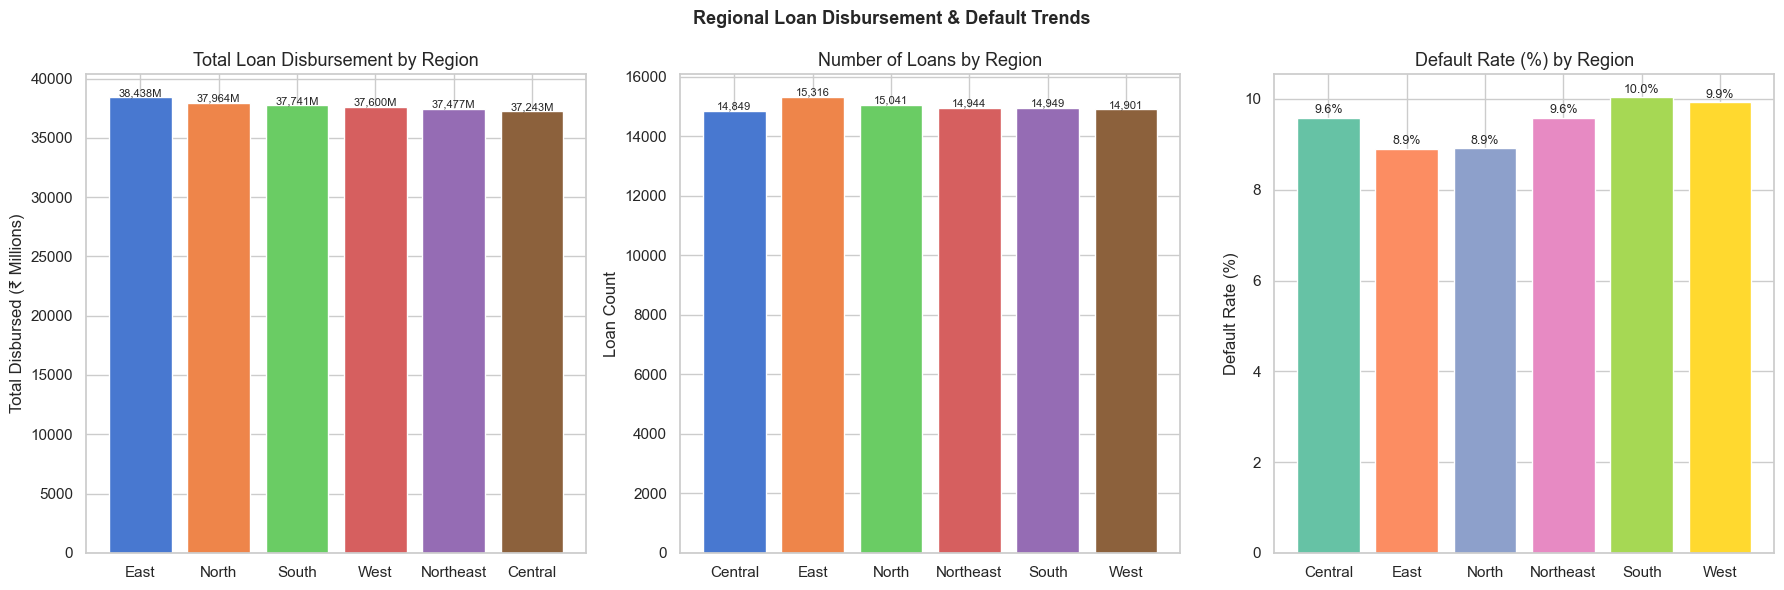

In [11]:
# Merge loans with customer region
loan_region = loan.merge(cust[['Customer_ID', 'Region']], on='Customer_ID', how='left')

reg_disburse = (loan_region.groupby('Region')['Loan_Amount']
                .sum().sort_values(ascending=False).reset_index())
reg_defaults = (loan_region.groupby('Region')['Default_Flag']
                .mean().mul(100).reset_index())
reg_defaults.columns = ['Region', 'Default_Rate_%']
reg_count = loan_region.groupby('Region')['Loan_ID'].count().reset_index()
reg_count.columns = ['Region', 'Loan_Count']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = sns.color_palette('muted', len(reg_disburse))

# Disbursement
bars1 = axes[0].bar(reg_disburse['Region'], reg_disburse['Loan_Amount'] / 1e6, color=colors, edgecolor='white')
axes[0].set_title('Total Loan Disbursement by Region')
axes[0].set_ylabel('Total Disbursed (₹ Millions)')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{bar.get_height():,.0f}M', ha='center', fontsize=8)

# Loan Count
bars2 = axes[1].bar(reg_count['Region'], reg_count['Loan_Count'], color=colors, edgecolor='white')
axes[1].set_title('Number of Loans by Region')
axes[1].set_ylabel('Loan Count')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{bar.get_height():,}', ha='center', fontsize=8)

# Default rate
bars3 = axes[2].bar(reg_defaults['Region'], reg_defaults['Default_Rate_%'],
                    color=sns.color_palette('Set2', len(reg_defaults)), edgecolor='white')
axes[2].set_title('Default Rate (%) by Region')
axes[2].set_ylabel('Default Rate (%)')
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.suptitle('Regional Loan Disbursement & Default Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.3 Monthly Trends in Loan Approvals and Disbursements

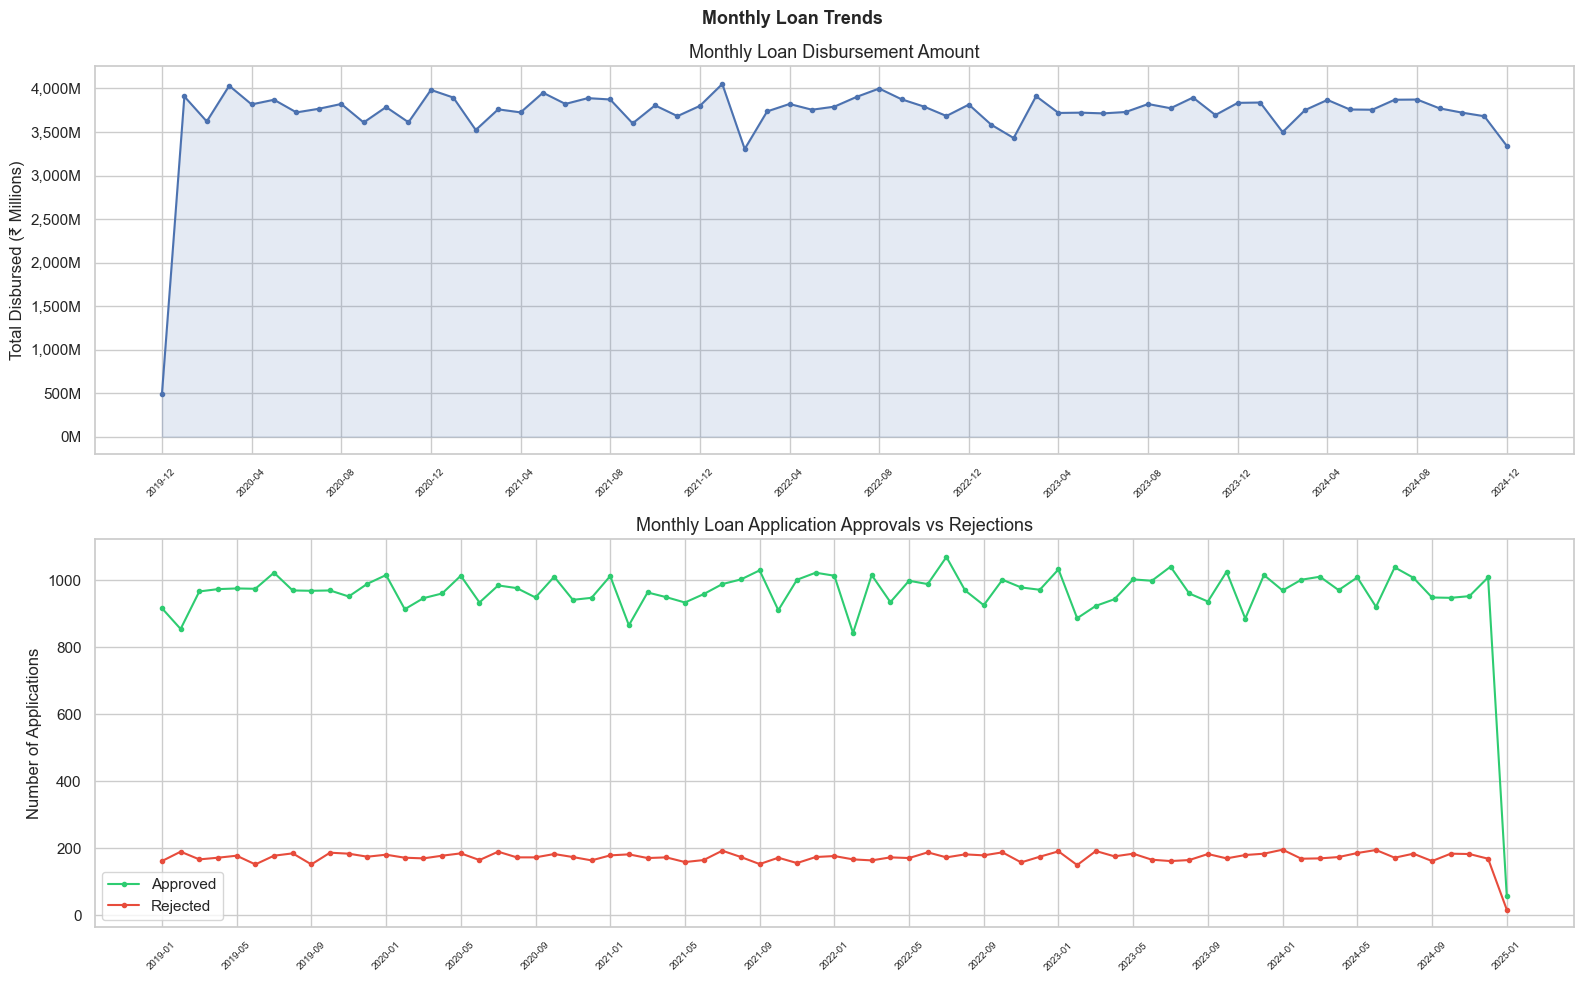

In [12]:
loan['Disbursal_YM'] = loan['Disbursal_Date'].dt.to_period('M')
monthly_disburse = loan.groupby('Disbursal_YM').agg(
    Count=('Loan_ID', 'count'),
    Total_Amount=('Loan_Amount', 'sum')
).reset_index()
monthly_disburse['Disbursal_YM'] = monthly_disburse['Disbursal_YM'].astype(str)

apps['App_YM'] = apps['Application_Date'].dt.to_period('M')
monthly_apps = (apps.groupby(['App_YM', 'Approval_Status'])
                .size().unstack(fill_value=0).reset_index())
monthly_apps['App_YM'] = monthly_apps['App_YM'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Monthly disbursements
axes[0].plot(monthly_disburse['Disbursal_YM'],
             monthly_disburse['Total_Amount'] / 1e6,
             color='#4C72B0', marker='o', markersize=3, linewidth=1.5)
axes[0].fill_between(range(len(monthly_disburse)),
                     monthly_disburse['Total_Amount'] / 1e6, alpha=0.15, color='#4C72B0')
axes[0].set_title('Monthly Loan Disbursement Amount')
axes[0].set_ylabel('Total Disbursed (₹ Millions)')
step0 = max(1, len(monthly_disburse) // 15)
axes[0].set_xticks(range(0, len(monthly_disburse), step0))
axes[0].set_xticklabels(monthly_disburse['Disbursal_YM'].iloc[::step0], rotation=45, fontsize=7)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))

# Monthly apps approved vs rejected
palette = {'Approved': '#2ecc71', 'Rejected': '#e74c3c'}
for status, color in palette.items():
    if status in monthly_apps.columns:
        axes[1].plot(monthly_apps['App_YM'], monthly_apps[status],
                     label=status, color=color, marker='o', markersize=3, linewidth=1.5)
axes[1].set_title('Monthly Loan Application Approvals vs Rejections')
axes[1].set_ylabel('Number of Applications')
step1 = max(1, len(monthly_apps) // 15)
axes[1].set_xticks(range(0, len(monthly_apps), step1))
axes[1].set_xticklabels(monthly_apps['App_YM'].iloc[::step1], rotation=45, fontsize=7)
axes[1].legend()

plt.suptitle('Monthly Loan Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# ⚠️ Task 3: Default Risk Analysis

> **Objectives**
> - Correlation between loan attributes and Default_Flag
> - Pairwise correlation heatmap of key variables
> - Correlation between branch metrics and default rates

---
## 3.1 Build Merged Analysis Dataset

In [13]:
# Merge loan + customer + defaults for risk analysis
loan_cust = loan.merge(
    cust[['Customer_ID', 'Age', 'Annual_Income', 'Credit_Score', 'Region']],
    on='Customer_ID', how='left'
)
loan_cust_def = loan_cust.merge(
    defs[['Loan_ID', 'Default_Amount', 'Recovery_Amount', 'Recovery_Status']],
    on='Loan_ID', how='left'
)
loan_cust_def['Default_Amount'].fillna(0, inplace=True)
loan_cust_def['Recovery_Amount'].fillna(0, inplace=True)
loan_cust_def['Recovery_Rate'] = np.where(
    loan_cust_def['Default_Amount'] > 0,
    (loan_cust_def['Recovery_Amount'] / loan_cust_def['Default_Amount'] * 100).clip(0, 100),
    0
)

print(f'Merged dataset: {loan_cust_def.shape}')
print('\nDefault_Flag distribution:')
vc = loan_cust_def['Default_Flag'].value_counts()
for v, c in vc.items():
    label = 'Defaulted' if v == 1 else 'Non-Defaulted'
    print(f'  {label}: {c:,}  ({c/len(loan_cust_def)*100:.1f}%)')

Merged dataset: (90461, 22)

Default_Flag distribution:
  Non-Defaulted: 81,461  (90.1%)
  Defaulted: 9,000  (9.9%)


## 3.2 Correlation Between Loan Attributes and Default_Flag

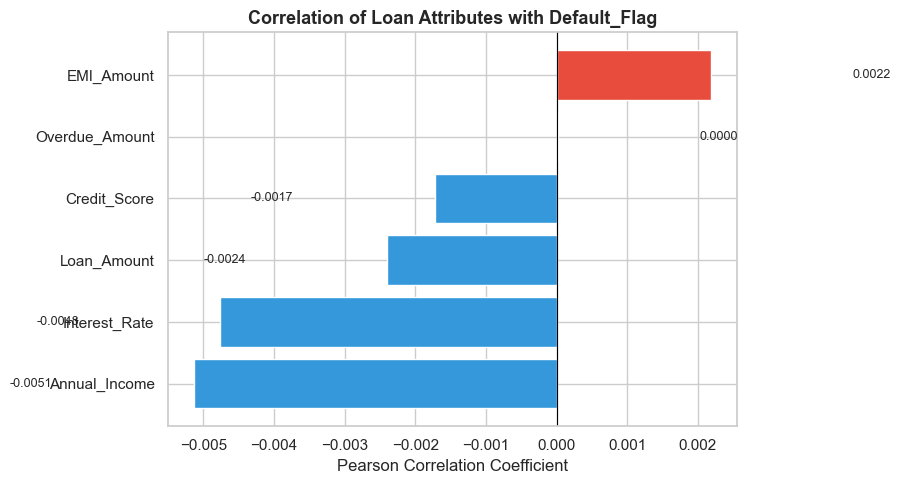

Correlation with Default_Flag:
Annual_Income    -0.01
Interest_Rate    -0.00
Loan_Amount      -0.00
Credit_Score     -0.00
Overdue_Amount    0.00
EMI_Amount        0.00


In [14]:
corr_cols = ['Loan_Amount', 'Interest_Rate', 'Credit_Score',
             'Annual_Income', 'EMI_Amount', 'Overdue_Amount', 'Default_Flag']
corr_data = loan_cust_def[corr_cols].dropna()
corr_with_default = (corr_data.corr()['Default_Flag']
                     .drop('Default_Flag')
                     .sort_values())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_default.values]
bars = ax.barh(corr_with_default.index, corr_with_default.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Loan Attributes with Default_Flag', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
for bar, val in zip(bars, corr_with_default.values):
    offset = 0.002 if val >= 0 else -0.002
    align  = 'left'  if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha=align, fontsize=9)
plt.tight_layout()
plt.show()

print('Correlation with Default_Flag:')
print(corr_with_default.to_string())

## 3.3 Pairwise Correlation Heatmap

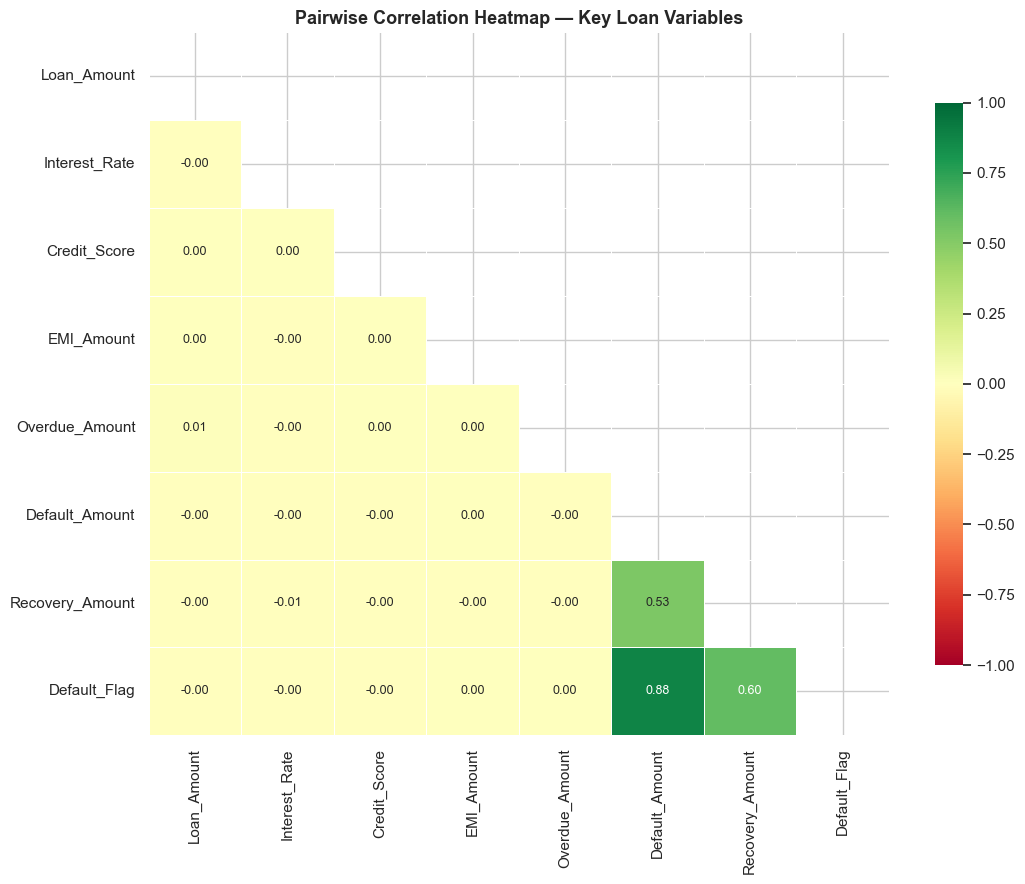

In [15]:
hm_cols = ['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'EMI_Amount',
           'Overdue_Amount', 'Default_Amount', 'Recovery_Amount', 'Default_Flag']
hm_data = loan_cust_def[hm_cols].dropna()
corr_matrix = hm_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, center=0,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
ax.set_title('Pairwise Correlation Heatmap — Key Loan Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.4 Branch Metrics Correlation with Default Rates

Branch Metrics (sample):
                 Branch_Name    Region  Delinquency_Rate  Default_Rate_%
        Dhar, Kant and Madan      West              7.53            9.93
                  Shan Group      East             12.41            8.90
            Sachdev-Banerjee   Central            137.70            9.58
                Kapadia-Brar      East              6.75            8.90
      Mangal, Kaur and Borde     South              5.39           10.04
                 Doshi Group     North              8.88            8.91
        Lad, Wali and Ramesh     North             42.74            8.91
                   Gala-Gara   Central             51.32            9.58
                  Vasa Group     North             44.92            8.91
                    Arya Ltd      West              2.71            9.93
                  Bhakta PLC     South              8.53           10.04
                    Kaul Inc      West              6.07            9.93
 Banik, Subramanian and Ma

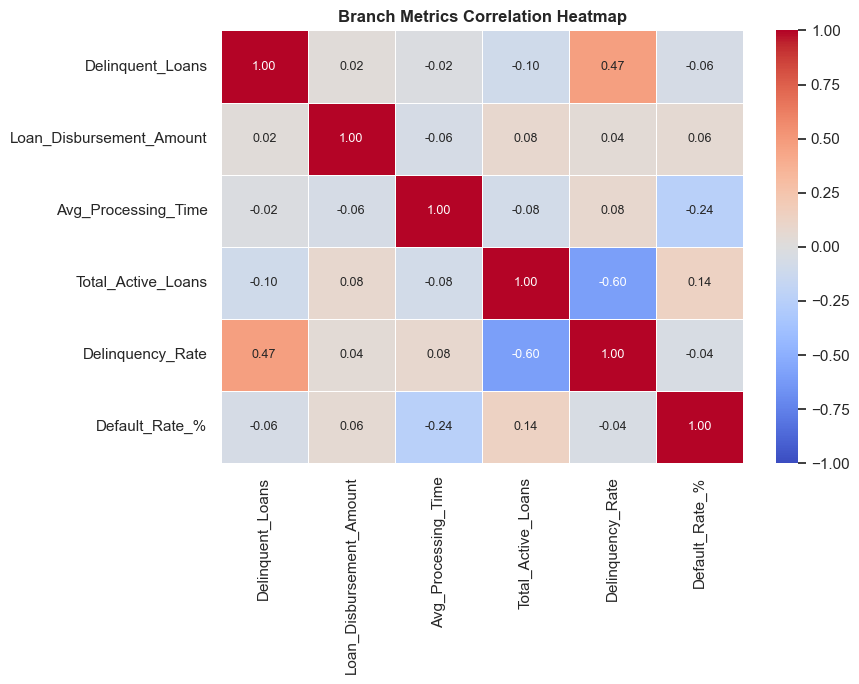

In [16]:
branch_perf = branch.copy()
branch_perf['Delinquency_Rate'] = (
    branch_perf['Delinquent_Loans'] / branch_perf['Total_Active_Loans'] * 100
).fillna(0)

# Default rate per region
reg_def_rate = loan_region.groupby('Region')['Default_Flag'].mean().mul(100).reset_index()
reg_def_rate.columns = ['Region', 'Default_Rate_%']
branch_perf = branch_perf.merge(reg_def_rate, on='Region', how='left')

br_num = branch_perf[['Delinquent_Loans', 'Loan_Disbursement_Amount',
                        'Avg_Processing_Time', 'Total_Active_Loans',
                        'Delinquency_Rate', 'Default_Rate_%']].dropna()

print('Branch Metrics (sample):')
print(branch_perf[['Branch_Name', 'Region', 'Delinquency_Rate', 'Default_Rate_%']].to_string(index=False))

if len(br_num) > 2:
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(br_num.corr(), annot=True, fmt='.2f', cmap='coolwarm',
                linewidths=0.5, ax=ax, vmin=-1, vmax=1, center=0,
                annot_kws={'size': 9})
    ax.set_title('Branch Metrics Correlation Heatmap', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
# 🏦 Task 4: Branch and Regional Performance

> **Objectives**
> - Rank branches by loan disbursement volume, processing time, default and recovery rates
> - Compare branch performance across regions

---
## 4.1 Branch Ranking — Loan Disbursement Volume

TOP BRANCHES BY DISBURSEMENT VOLUME:
                     Branch_Name     Region  Loan_Disbursement_Amount  Total_Active_Loans
1                      Kara-Bahl       East                 499562869                 949
2            Bhatti, Rau and Sem      North                 482327541                 439
3                       Kaul Inc       West                 465469874                1714
4             Chawla-Subramanian    Central                 464419943                1601
5   Malhotra, Boase and Malhotra    Central                 449109596                 618
6                   Grover Group       East                 447832443                 872
7               Sachdev-Banerjee    Central                 445787808                 122
8                      Sani-Kale      North                 442594434                 323
9                       Arya Ltd       West                 435407779                1810
10                      Yogi Ltd      North                 420

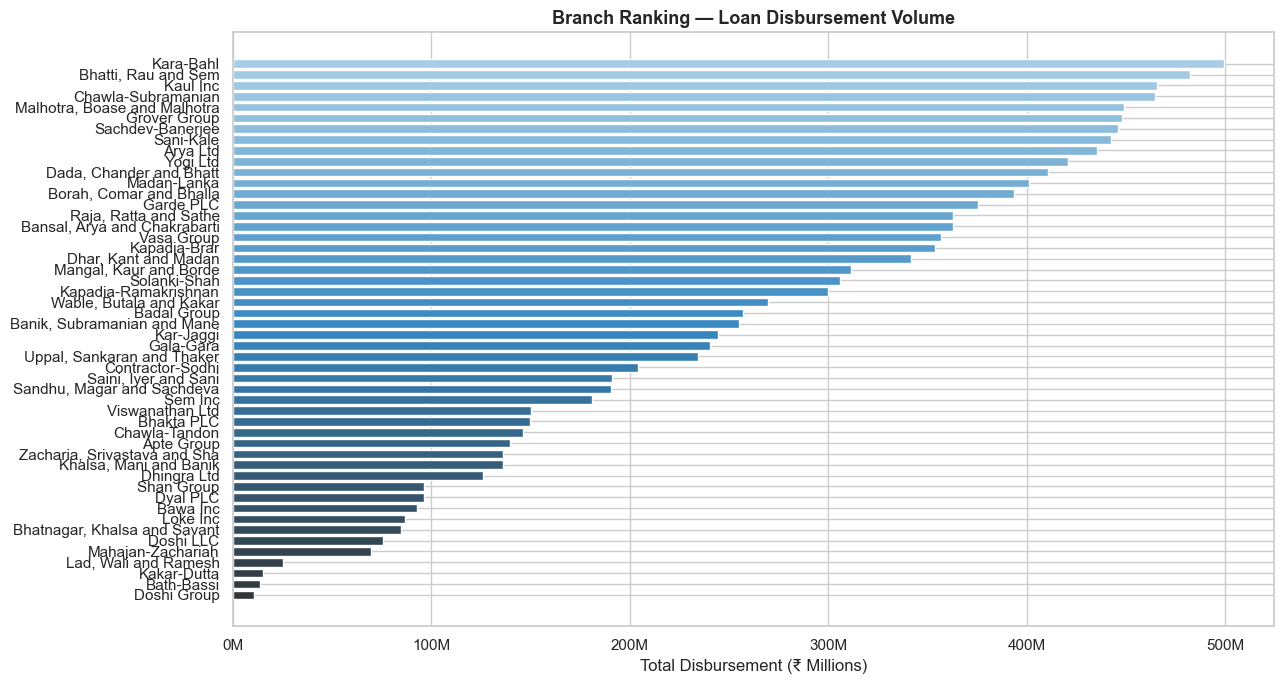

In [17]:
bp = branch_perf.sort_values('Loan_Disbursement_Amount', ascending=False).reset_index(drop=True)
bp.index += 1
print('TOP BRANCHES BY DISBURSEMENT VOLUME:')
print(bp[['Branch_Name', 'Region', 'Loan_Disbursement_Amount', 'Total_Active_Loans']].to_string())

fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette('Blues_d', len(bp))[::-1]
ax.barh(bp['Branch_Name'][::-1], bp['Loan_Disbursement_Amount'][::-1] / 1e6,
        color=palette, edgecolor='white')
ax.set_title('Branch Ranking — Loan Disbursement Volume', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Disbursement (₹ Millions)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))
plt.tight_layout()
plt.show()

## 4.2 Branch Ranking — Processing Time Efficiency

BRANCHES BY PROCESSING TIME (fastest first):
                     Branch_Name     Region  Avg_Processing_Time
1                      Sani-Kale      North                    1
2     Sandhu, Magar and Sachdeva  Northeast                    2
3                  Chawla-Tandon       East                    2
4                      Kar-Jaggi       West                    2
5                   Solanki-Shah      South                    3
6                       Kaul Inc       West                    3
7           Kapadia-Ramakrishnan       West                    3
8             Chawla-Subramanian    Central                    4
9           Saini, Iyer and Sani      South                    5
10       Wable, Butala and Kakar      South                    5
11                      Loke Inc  Northeast                    6
12                      Bawa Inc    Central                    6
13               Viswanathan Ltd      South                    6
14          Dhar, Kant and Madan       West  

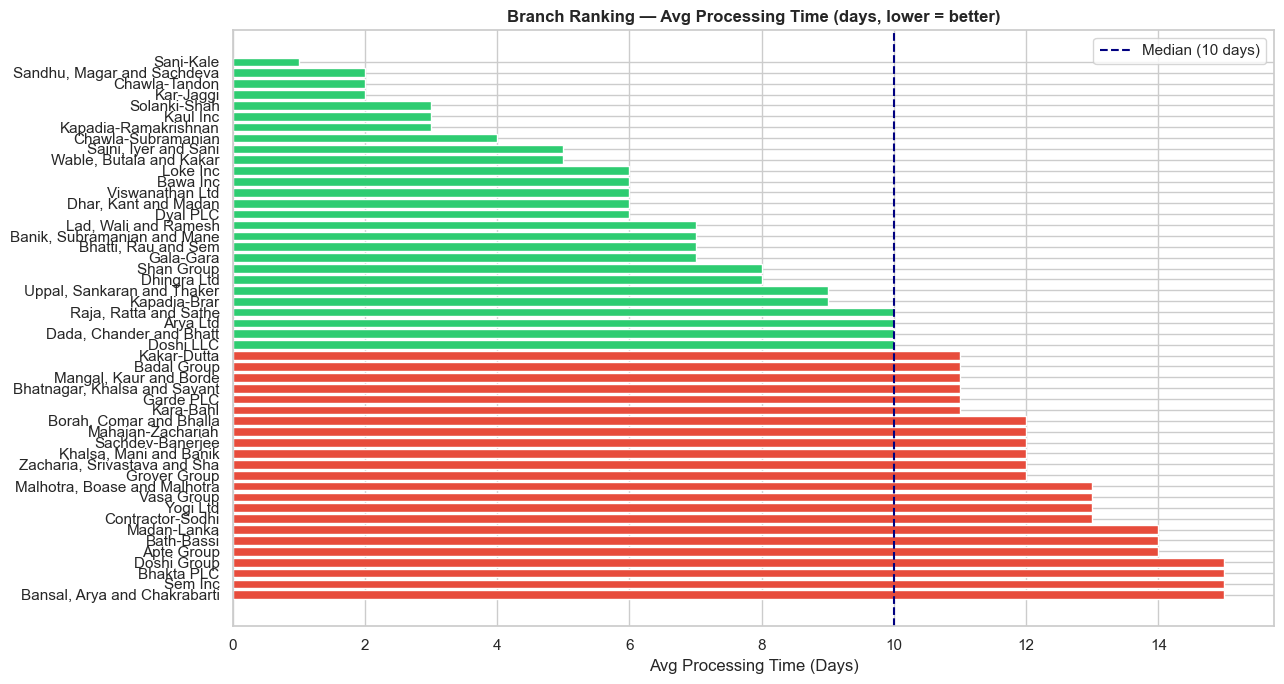

In [18]:
proc_rank = branch_perf.sort_values('Avg_Processing_Time').reset_index(drop=True)
proc_rank.index += 1
median_proc = proc_rank['Avg_Processing_Time'].median()

print('BRANCHES BY PROCESSING TIME (fastest first):')
print(proc_rank[['Branch_Name', 'Region', 'Avg_Processing_Time']].to_string())

fig, ax = plt.subplots(figsize=(13, 7))
colors = ['#2ecc71' if t <= median_proc else '#e74c3c'
          for t in proc_rank['Avg_Processing_Time']]
ax.barh(proc_rank['Branch_Name'][::-1], proc_rank['Avg_Processing_Time'][::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(median_proc, color='navy', linestyle='--', linewidth=1.5,
           label=f'Median ({median_proc:.0f} days)')
ax.set_title('Branch Ranking — Avg Processing Time (days, lower = better)', fontsize=12, fontweight='bold')
ax.set_xlabel('Avg Processing Time (Days)')
ax.legend()
plt.tight_layout()
plt.show()

## 4.3 Branch Ranking — Delinquency Rate

BRANCHES BY DELINQUENCY RATE (lowest = best):
                     Branch_Name     Region  Delinquent_Loans  Total_Active_Loans  Delinquency_Rate
1        Dada, Chander and Bhatt      North                10                1933              0.52
2                    Kakar-Dutta       East                18                1849              0.97
3                  Chawla-Tandon       East                16                1113              1.44
4           Kapadia-Ramakrishnan       West                18                 830              2.17
5                    Badal Group    Central                43                1648              2.61
6                       Arya Ltd       West                49                1810              2.71
7                        Sem Inc      South                22                 776              2.84
8                       Dyal PLC  Northeast                49                1715              2.86
9               Contractor-Sodhi       West           

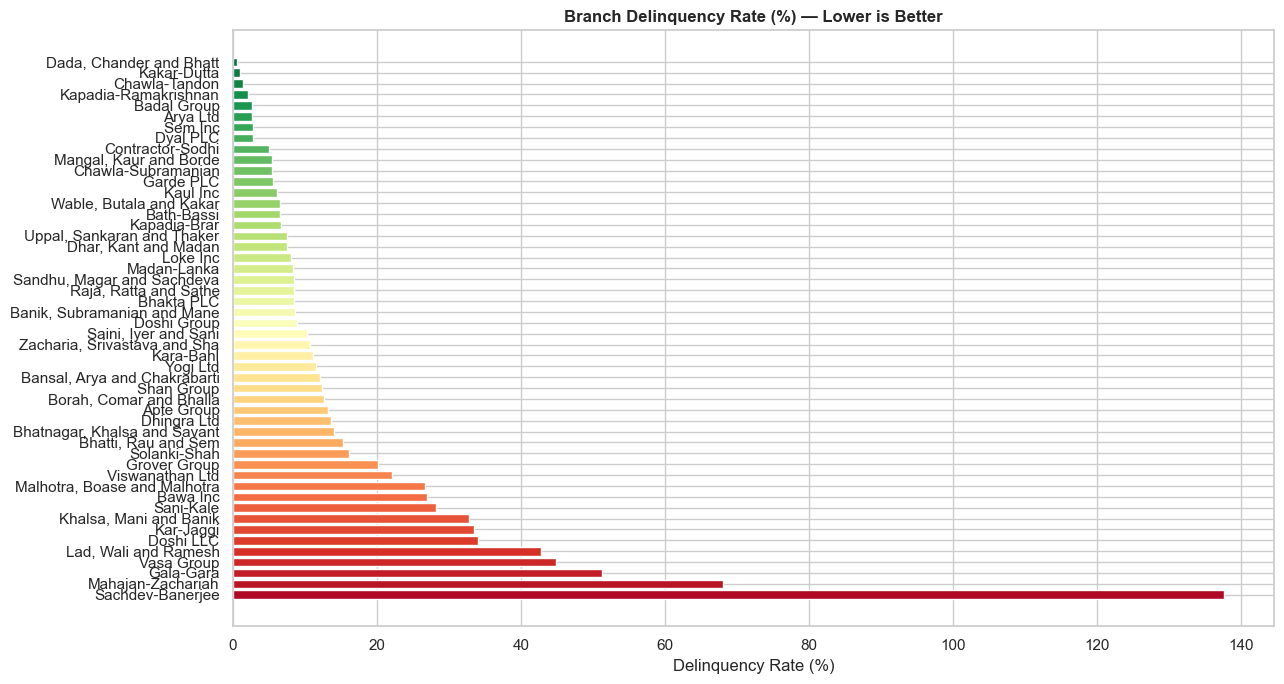

In [19]:
delinq_rank = branch_perf.sort_values('Delinquency_Rate').reset_index(drop=True)
delinq_rank.index += 1
print('BRANCHES BY DELINQUENCY RATE (lowest = best):')
print(delinq_rank[['Branch_Name', 'Region', 'Delinquent_Loans',
                    'Total_Active_Loans', 'Delinquency_Rate']].to_string())

fig, ax = plt.subplots(figsize=(13, 7))
colors = sns.color_palette('RdYlGn_r', len(delinq_rank))
ax.barh(delinq_rank['Branch_Name'][::-1], delinq_rank['Delinquency_Rate'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Branch Delinquency Rate (%) — Lower is Better', fontsize=12, fontweight='bold')
ax.set_xlabel('Delinquency Rate (%)')
plt.tight_layout()
plt.show()

## 4.4 Regional Performance Comparison

Regional Performance Summary:
   Region  Avg_Disbursement_M  Avg_Delinquency_Rate  Avg_Processing_Days  Total_Active_Loans  Branch_Count
  Central              331.60                 28.51                 9.50                8715            10
     East              250.83                  9.88                 9.88                8929             8
    North              235.43                 19.23                10.36               11965            14
Northeast              110.71                 21.90                 6.50                5174             4
    South              211.86                 10.32                 9.00                9235             8
     West              331.80                  9.52                 6.17                6861             6


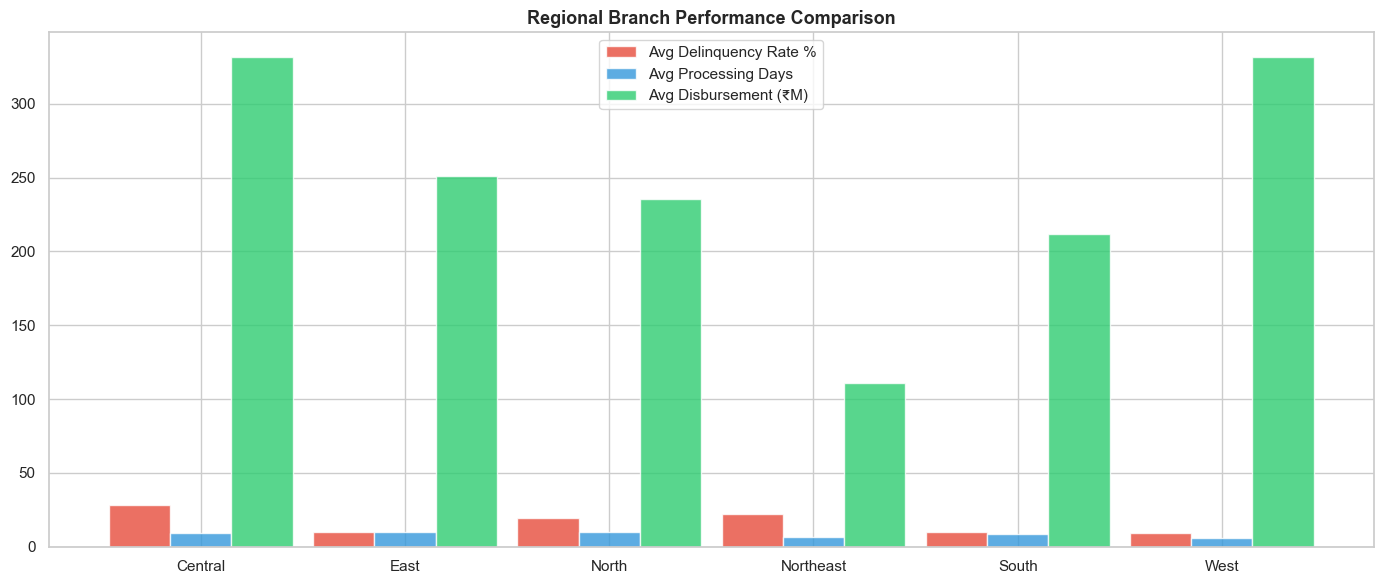

In [20]:
region_perf = branch_perf.groupby('Region').agg(
    Avg_Disbursement_M=('Loan_Disbursement_Amount', lambda x: x.mean() / 1e6),
    Avg_Delinquency_Rate=('Delinquency_Rate', 'mean'),
    Avg_Processing_Days=('Avg_Processing_Time', 'mean'),
    Total_Active_Loans=('Total_Active_Loans', 'sum'),
    Branch_Count=('Branch_ID', 'count')
).round(2).reset_index()

print('Regional Performance Summary:')
print(region_perf.to_string(index=False))

x = np.arange(len(region_perf))
w = 0.3
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w, region_perf['Avg_Delinquency_Rate'], width=w, label='Avg Delinquency Rate %',
       color='#e74c3c', alpha=0.8, edgecolor='white')
ax.bar(x,     region_perf['Avg_Processing_Days'],  width=w, label='Avg Processing Days',
       color='#3498db', alpha=0.8, edgecolor='white')
ax.bar(x + w, region_perf['Avg_Disbursement_M'],   width=w, label='Avg Disbursement (₹M)',
       color='#2ecc71', alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(region_perf['Region'])
ax.set_title('Regional Branch Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
# 👥 Task 5: Customer Segmentation

> **Objectives**
> - Segment customers by income, credit score, and loan status
> - Identify high-risk and high-value customer groups
> - Analyze repayment behavior across segments

---
## 5.1 Create Customer Segments

In [21]:
cust_seg = cust.copy()

# Credit score segments
cust_seg['Credit_Segment'] = pd.cut(
    cust_seg['Credit_Score'],
    bins=[0, 500, 600, 700, 800, 900],
    labels=['Poor\n(<500)', 'Fair\n(500-600)', 'Good\n(600-700)',
            'Very Good\n(700-800)', 'Excellent\n(800+)']
)

# Income quartile segments
cust_seg['Income_Segment'] = pd.qcut(
    cust_seg['Annual_Income'], q=4,
    labels=['Low Income', 'Lower-Mid', 'Upper-Mid', 'High Income']
)

# Merge with loan data
cust_loan = cust_seg.merge(
    loan[['Customer_ID', 'Loan_Status', 'Default_Flag',
          'Loan_Amount', 'EMI_Amount', 'Overdue_Amount']],
    on='Customer_ID', how='left'
)
cust_loan['Loan_Status'].fillna('No Loan', inplace=True)
cust_loan['Default_Flag'].fillna(0, inplace=True)

print('Credit Segment Distribution:')
print(cust_seg['Credit_Segment'].value_counts().sort_index().to_string())
print('\nIncome Segment Distribution:')
print(cust_seg['Income_Segment'].value_counts().sort_index().to_string())

Credit Segment Distribution:
Credit_Segment
Poor\n(<500)            25656
Fair\n(500-600)         12804
Good\n(600-700)         12518
Very Good\n(700-800)    12535
Excellent\n(800+)        6487

Income Segment Distribution:
Income_Segment
Low Income     17500
Lower-Mid      17500
Upper-Mid      17500
High Income    17500


## 5.2 Segment Distribution Visualisations

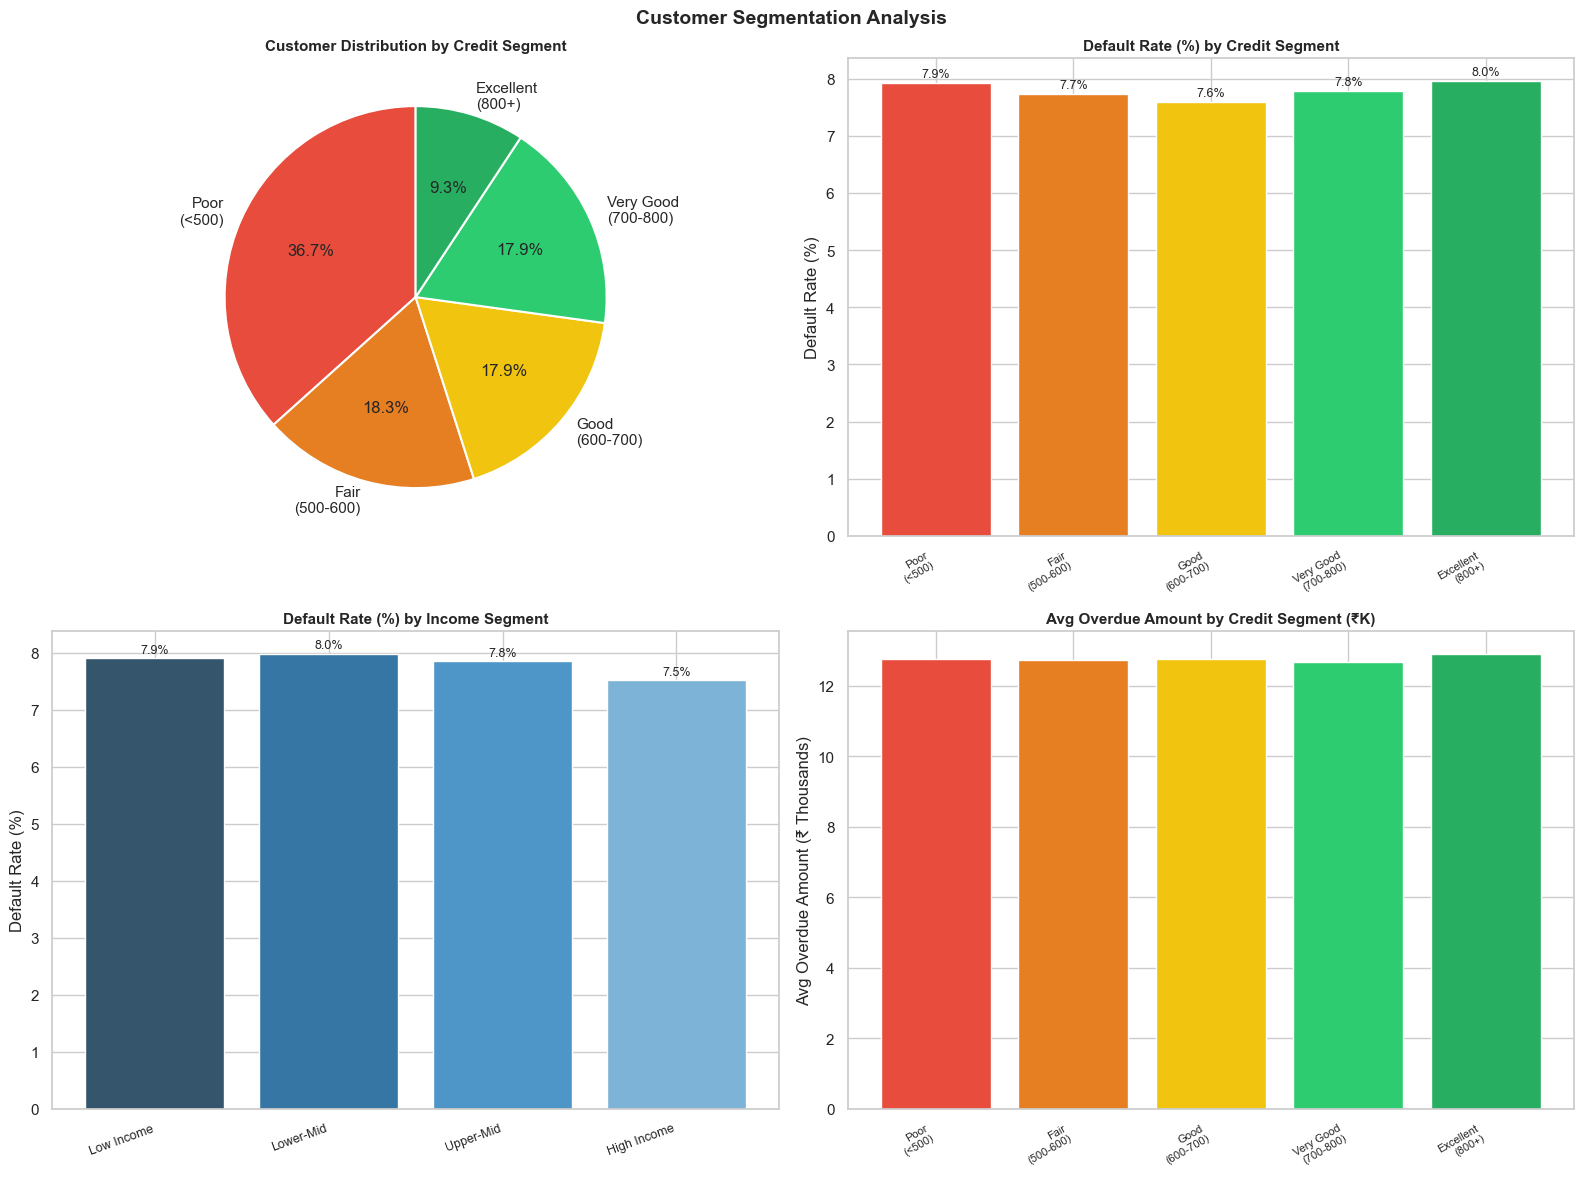

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Credit segment pie
seg_count = cust_seg['Credit_Segment'].value_counts().sort_index()
wedge_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0, 0].pie(seg_count.values, labels=seg_count.index, autopct='%1.1f%%',
               colors=wedge_colors, startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0, 0].set_title('Customer Distribution by Credit Segment', fontsize=11, fontweight='bold')

# 2. Default rate by credit segment
dr_cs = cust_loan.groupby('Credit_Segment', observed=False)['Default_Flag'].mean().mul(100)
axes[0, 1].bar(range(len(dr_cs)), dr_cs.values, color=wedge_colors, edgecolor='white')
axes[0, 1].set_xticks(range(len(dr_cs)))
axes[0, 1].set_xticklabels(dr_cs.index.astype(str), rotation=30, ha='right', fontsize=8)
axes[0, 1].set_title('Default Rate (%) by Credit Segment', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Default Rate (%)')
for i, v in enumerate(dr_cs.values):
    axes[0, 1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

# 3. Default rate by income segment
dr_inc = cust_loan.groupby('Income_Segment', observed=False)['Default_Flag'].mean().mul(100)
inc_colors = sns.color_palette('Blues_d', len(dr_inc))[::-1]
axes[1, 0].bar(range(len(dr_inc)), dr_inc.values, color=inc_colors, edgecolor='white')
axes[1, 0].set_xticks(range(len(dr_inc)))
axes[1, 0].set_xticklabels(dr_inc.index.astype(str), rotation=20, ha='right', fontsize=9)
axes[1, 0].set_title('Default Rate (%) by Income Segment', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Default Rate (%)')
for i, v in enumerate(dr_inc.values):
    axes[1, 0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

# 4. Avg Overdue by credit segment
avg_ov = cust_loan.groupby('Credit_Segment', observed=False)['Overdue_Amount'].mean()
axes[1, 1].bar(range(len(avg_ov)), avg_ov.values / 1e3, color=wedge_colors, edgecolor='white')
axes[1, 1].set_xticks(range(len(avg_ov)))
axes[1, 1].set_xticklabels(avg_ov.index.astype(str), rotation=30, ha='right', fontsize=8)
axes[1, 1].set_title('Avg Overdue Amount by Credit Segment (₹K)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Avg Overdue Amount (₹ Thousands)')

plt.suptitle('Customer Segmentation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.3 High-Risk vs High-Value Customer Identification

Customer Segment Summary:
               Count  Avg_Credit_Score  Avg_Annual_Income  Avg_Loan_Amount  Avg_Overdue  Default_Rate
Customer_Type                                                                                        
High-Risk       4712            448.41         1088918.45       2503874.54     12621.74          1.00
High-Value      6760            774.67         1773060.87       2523871.07     12716.47          0.00
Standard       97852            566.72         1054060.98       2516470.85     12755.17          0.04


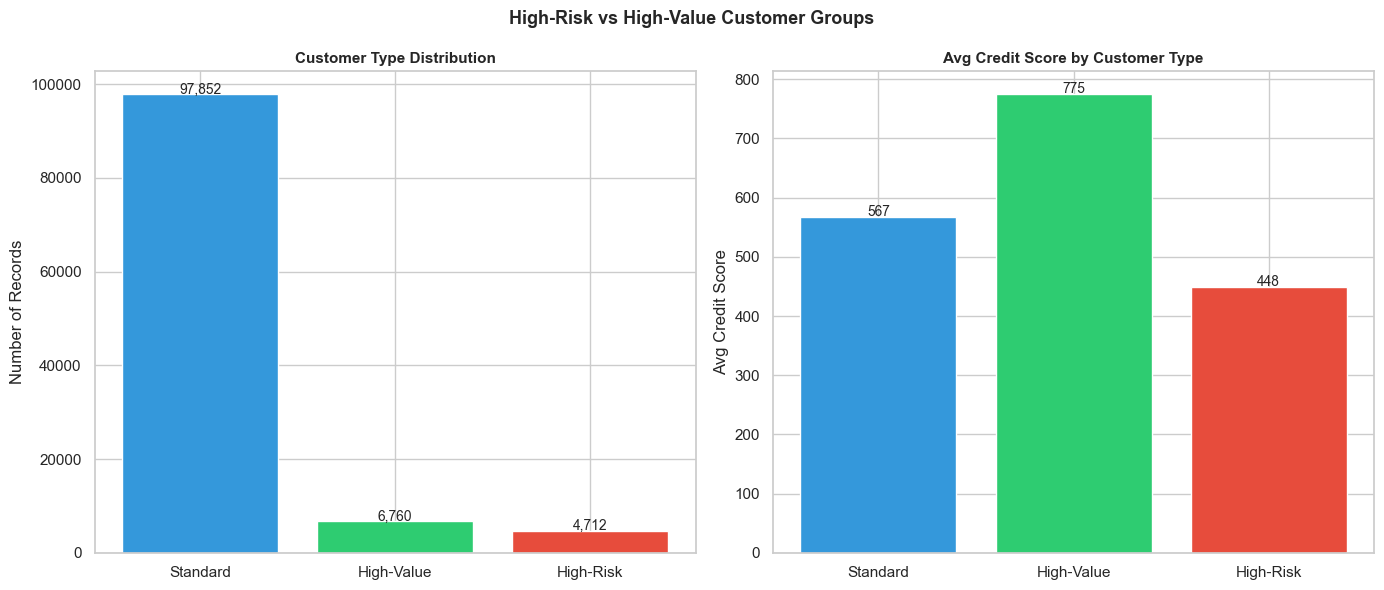

In [23]:
income_75 = cust['Annual_Income'].quantile(0.75)

cust_loan = cust_loan.copy()
cust_loan['Customer_Type'] = 'Standard'
cust_loan.loc[(cust_loan['Default_Flag'] == 1) &
              (cust_loan['Credit_Score'] < 600), 'Customer_Type'] = 'High-Risk'
cust_loan.loc[(cust_loan['Default_Flag'] == 0) &
              (cust_loan['Credit_Score'] >= 700) &
              (cust_loan['Annual_Income'] >= income_75), 'Customer_Type'] = 'High-Value'

seg_summary = cust_loan.groupby('Customer_Type').agg(
    Count=('Customer_ID', 'count'),
    Avg_Credit_Score=('Credit_Score', 'mean'),
    Avg_Annual_Income=('Annual_Income', 'mean'),
    Avg_Loan_Amount=('Loan_Amount', 'mean'),
    Avg_Overdue=('Overdue_Amount', 'mean'),
    Default_Rate=('Default_Flag', 'mean')
).round(2)
print('Customer Segment Summary:')
print(seg_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ct = cust_loan['Customer_Type'].value_counts()
colors_ct = {'High-Risk': '#e74c3c', 'Standard': '#3498db', 'High-Value': '#2ecc71'}
bar_colors = [colors_ct.get(t, '#95a5a6') for t in ct.index]
bars = axes[0].bar(ct.index, ct.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Customer Type Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Records')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{bar.get_height():,}', ha='center', fontsize=10)

# Avg credit score by type
avg_cs = cust_loan.groupby('Customer_Type')['Credit_Score'].mean().reindex(ct.index)
axes[1].bar(avg_cs.index, avg_cs.values, color=bar_colors, edgecolor='white')
axes[1].set_title('Avg Credit Score by Customer Type', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Avg Credit Score')
for i, v in enumerate(avg_cs.values):
    axes[1].text(i, v + 2, f'{v:.0f}', ha='center', fontsize=10)

plt.suptitle('High-Risk vs High-Value Customer Groups', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.4 Repayment Behavior Across Segments

Repayment Behaviour by Credit Segment (EMI transactions):
      Credit_Segment  Total_EMI_Paid  Avg_EMI_Payment  Transaction_Count
        Poor\n(<500)      2326227753         25421.03              91508
     Fair\n(500-600)      1150492140         25571.04              44992
     Good\n(600-700)      1119197306         25505.28              43881
Very Good\n(700-800)      1116302251         25526.57              43731
   Excellent\n(800+)       590337567         25617.84              23044


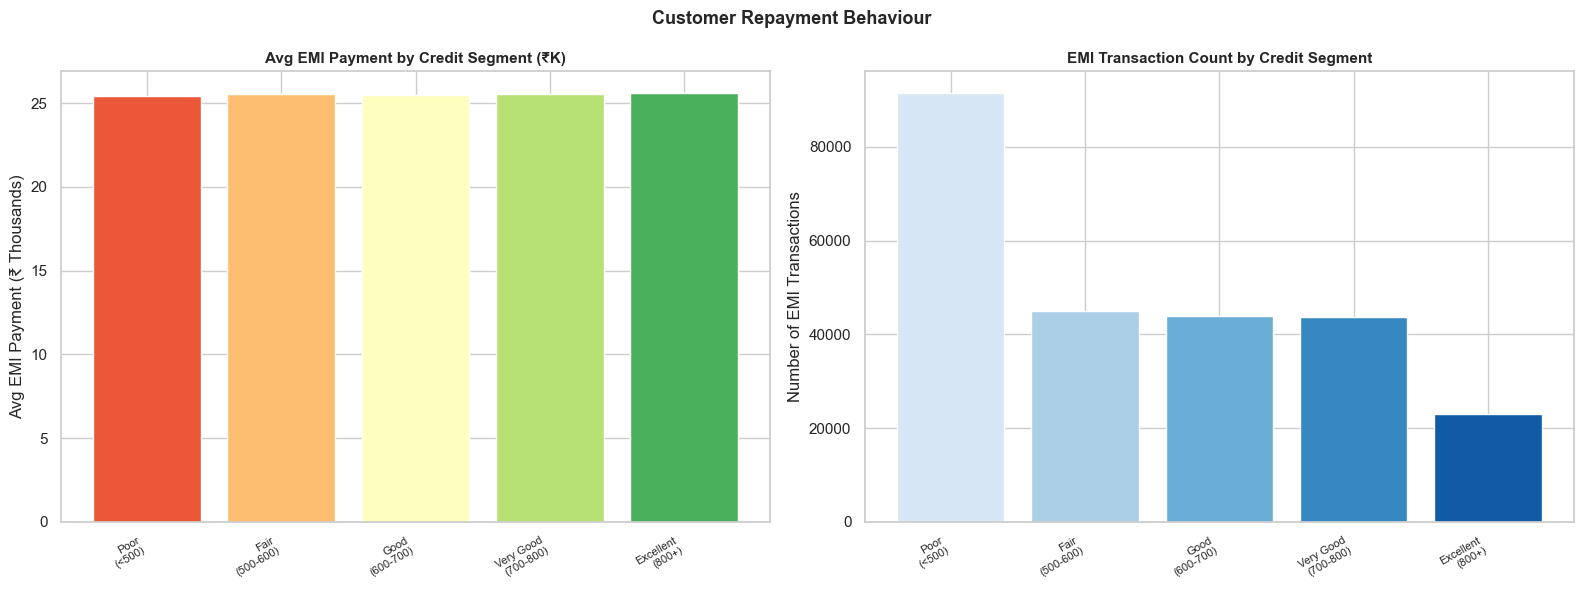

In [24]:
# Map credit segment to transactions
cust_loan_map = cust_loan[['Customer_ID','Credit_Segment','Income_Segment','Customer_Type']].drop_duplicates('Customer_ID')
txn_seg = txn.merge(cust_loan_map, on='Customer_ID', how='left')

emi_txn = txn_seg[txn_seg['Payment_Type'] == 'Emi']
repay_seg = emi_txn.groupby('Credit_Segment', observed=False).agg(
    Total_EMI_Paid=('Amount', 'sum'),
    Avg_EMI_Payment=('Amount', 'mean'),
    Transaction_Count=('Transaction_ID', 'count')
).reset_index()

print('Repayment Behaviour by Credit Segment (EMI transactions):')
print(repay_seg.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
seg_labels = repay_seg['Credit_Segment'].astype(str)

axes[0].bar(range(len(repay_seg)), repay_seg['Avg_EMI_Payment'] / 1e3,
            color=sns.color_palette('RdYlGn', len(repay_seg)), edgecolor='white')
axes[0].set_xticks(range(len(repay_seg)))
axes[0].set_xticklabels(seg_labels, rotation=30, ha='right', fontsize=8)
axes[0].set_title('Avg EMI Payment by Credit Segment (₹K)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Avg EMI Payment (₹ Thousands)')

axes[1].bar(range(len(repay_seg)), repay_seg['Transaction_Count'],
            color=sns.color_palette('Blues', len(repay_seg)), edgecolor='white')
axes[1].set_xticks(range(len(repay_seg)))
axes[1].set_xticklabels(seg_labels, rotation=30, ha='right', fontsize=8)
axes[1].set_title('EMI Transaction Count by Credit Segment', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of EMI Transactions')

plt.suptitle('Customer Repayment Behaviour', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 📐 Task 6: Advanced Statistical Analysis

> **Objectives**
> 1. Correlation analysis for default risks (Pearson + Spearman)
> 2. Pairwise correlation heatmap (EMI, Recovery Rate, Default Amount)
> 3. Branch-level correlation exploration

---
## 6.1 Pearson & Spearman Correlation — Default Risk Factors

In [25]:
risk_df = loan_cust_def[['Credit_Score', 'Loan_Amount', 'Interest_Rate',
                           'Overdue_Amount', 'EMI_Amount', 'Default_Flag',
                           'Default_Amount', 'Recovery_Amount']].dropna()

print(f'{"Variable":>25s}  {"Pearson r":>10}  {"Spearman r":>11}  {"p-value":>12}')
print('─' * 65)
target = risk_df['Default_Flag']
for col in ['Credit_Score', 'Loan_Amount', 'Interest_Rate', 'Overdue_Amount', 'EMI_Amount']:
    p_r, p_p = stats.pearsonr(risk_df[col], target)
    s_r, _   = stats.spearmanr(risk_df[col], target)
    sig = '***' if p_p < 0.001 else ('**' if p_p < 0.01 else ('*' if p_p < 0.05 else ''))
    print(f'{col:>25s}  {p_r:>10.4f}  {s_r:>11.4f}  {p_p:>12.2e} {sig}')

print('\nSignificance: *** p<0.001  ** p<0.01  * p<0.05')

                 Variable   Pearson r   Spearman r       p-value
─────────────────────────────────────────────────────────────────
             Credit_Score     -0.0017      -0.0017      6.04e-01 
              Loan_Amount     -0.0024      -0.0024      4.70e-01 
            Interest_Rate     -0.0048      -0.0048      1.52e-01 
           Overdue_Amount      0.0000      -0.0007      9.95e-01 
               EMI_Amount      0.0022       0.0022      5.11e-01 

Significance: *** p<0.001  ** p<0.01  * p<0.05


## 6.2 Comprehensive Pairwise Correlation Heatmap

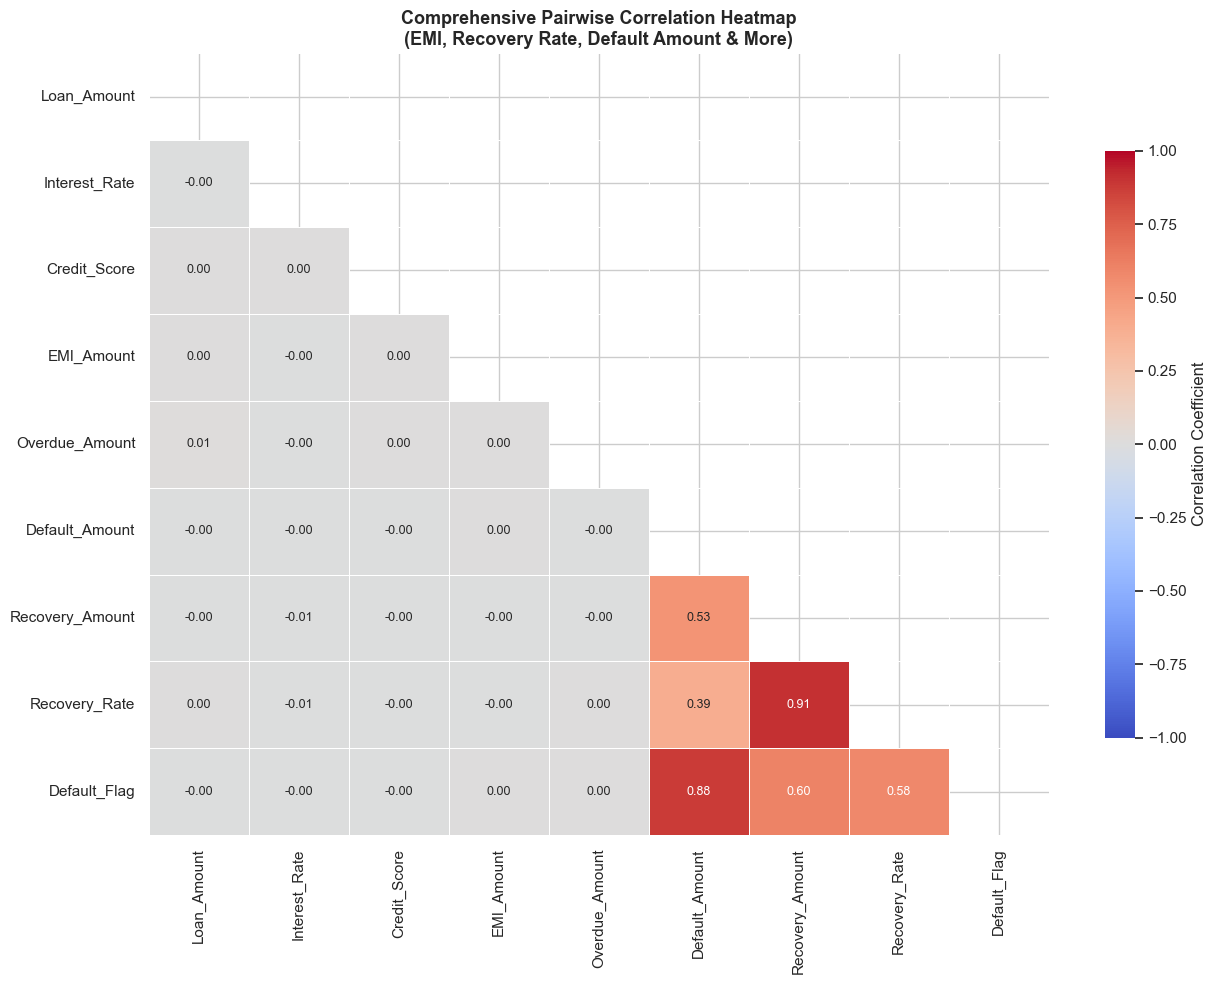

In [26]:
hm_cols2 = ['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'EMI_Amount',
            'Overdue_Amount', 'Default_Amount', 'Recovery_Amount',
            'Recovery_Rate', 'Default_Flag']
hm2 = loan_cust_def[hm_cols2].dropna()
corr2 = hm2.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=ax, vmin=-1, vmax=1, center=0,
            cbar_kws={'shrink': 0.75, 'label': 'Correlation Coefficient'},
            annot_kws={'size': 9})
ax.set_title('Comprehensive Pairwise Correlation Heatmap\n(EMI, Recovery Rate, Default Amount & More)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.3 Branch-Level Correlation Analysis

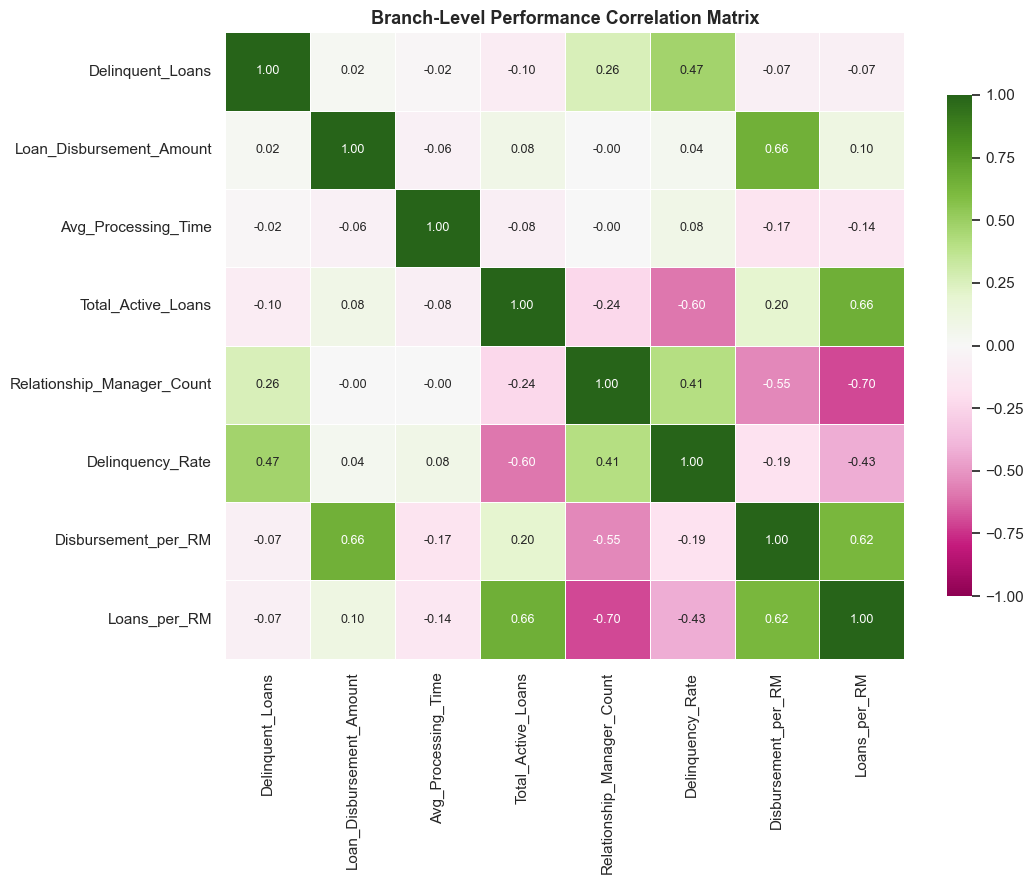


Branch Performance Metrics Table:
                 Branch_Name    Region  Delinquency_Rate  Disbursement_per_RM  Loans_per_RM  Avg_Processing_Time
        Dhar, Kant and Madan      West              7.53          11782099.38          9.62                    6
                  Shan Group      East             12.41           2758543.40         34.31                    8
            Sachdev-Banerjee   Central            137.70           9287246.00          2.54                   12
                Kapadia-Brar      East              6.75           7078685.98         28.44                    9
      Mangal, Kaur and Borde     South              5.39          31163790.20        161.30                   11
                 Doshi Group     North              8.88           1490742.43        122.29                   15
        Lad, Wali and Ramesh     North             42.74            839703.47         15.60                    7
                   Gala-Gara   Central             51.32     

In [27]:
branch_full = branch_perf.copy()
branch_full['Disbursement_per_RM'] = (
    branch_full['Loan_Disbursement_Amount'] / branch_full['Relationship_Manager_Count']
)
branch_full['Loans_per_RM'] = (
    branch_full['Total_Active_Loans'] / branch_full['Relationship_Manager_Count']
)

br_cols = ['Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Processing_Time',
           'Total_Active_Loans', 'Relationship_Manager_Count',
           'Delinquency_Rate', 'Disbursement_per_RM', 'Loans_per_RM']
br_corr = branch_full[br_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(br_corr, annot=True, fmt='.2f', cmap='PiYG',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, center=0,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
ax.set_title('Branch-Level Performance Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nBranch Performance Metrics Table:')
display_cols = ['Branch_Name', 'Region', 'Delinquency_Rate',
                'Disbursement_per_RM', 'Loans_per_RM', 'Avg_Processing_Time']
print(branch_full[display_cols].to_string(index=False))

---
# 💸 Task 7: Transaction and Recovery Analysis

> **Objectives**
> - Analyze penalty payments and overdue trends
> - Evaluate recovery rates by Default_Reason and Legal_Action
> - Compare recovery rates across regions and branches

---
## 7.1 Penalty Payment and Overdue Trends

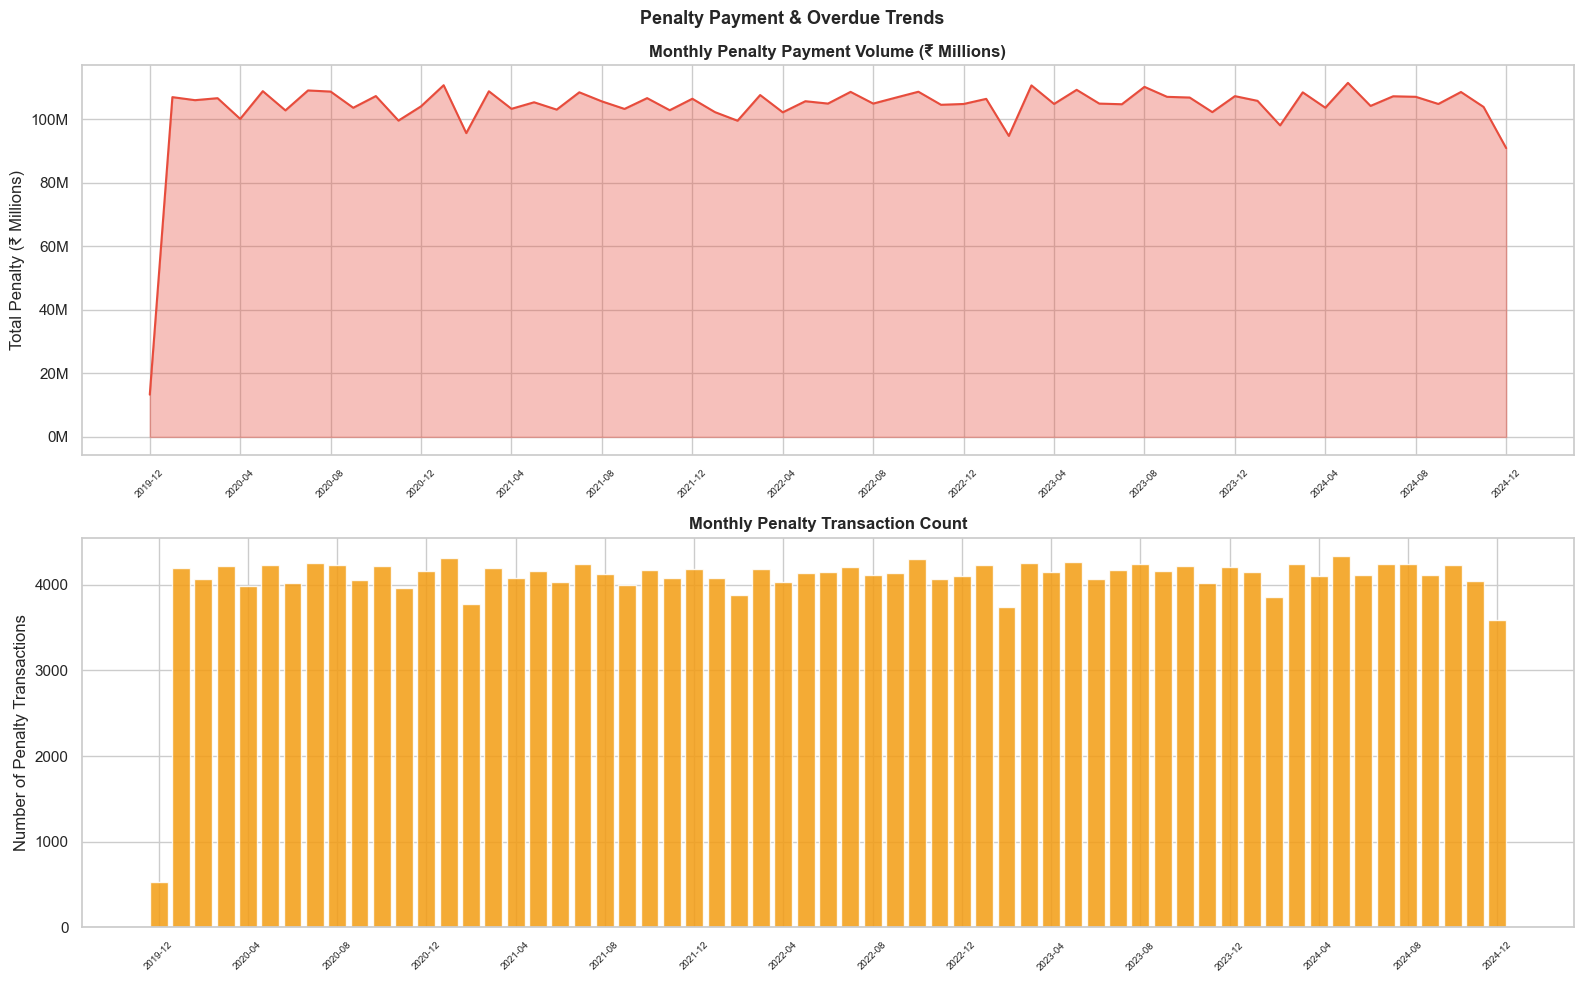

In [28]:
penalty_txn = txn[txn['Payment_Type'] == 'Penalty'].copy()
penalty_txn['YM'] = penalty_txn['Transaction_Date'].dt.to_period('M')
monthly_pen = penalty_txn.groupby('YM').agg(
    Count=('Transaction_ID', 'count'),
    Total_Penalty=('Amount', 'sum'),
    Avg_Overdue_Fee=('Overdue_Fee', 'mean')
).reset_index()
monthly_pen['YM'] = monthly_pen['YM'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
step = max(1, len(monthly_pen) // 15)
x = range(len(monthly_pen))
xtick_pos = range(0, len(monthly_pen), step)
xtick_labels = monthly_pen['YM'].iloc[::step]

axes[0].fill_between(x, monthly_pen['Total_Penalty'] / 1e6, alpha=0.35, color='#e74c3c')
axes[0].plot(x, monthly_pen['Total_Penalty'] / 1e6, color='#e74c3c', linewidth=1.5)
axes[0].set_xticks(xtick_pos)
axes[0].set_xticklabels(xtick_labels, rotation=45, fontsize=7)
axes[0].set_title('Monthly Penalty Payment Volume (₹ Millions)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Penalty (₹ Millions)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))

axes[1].bar(x, monthly_pen['Count'], color='#f39c12', edgecolor='white', alpha=0.85)
axes[1].set_xticks(xtick_pos)
axes[1].set_xticklabels(xtick_labels, rotation=45, fontsize=7)
axes[1].set_title('Monthly Penalty Transaction Count', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Penalty Transactions')

plt.suptitle('Penalty Payment & Overdue Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7.2 Recovery Rates by Default Reason and Legal Action

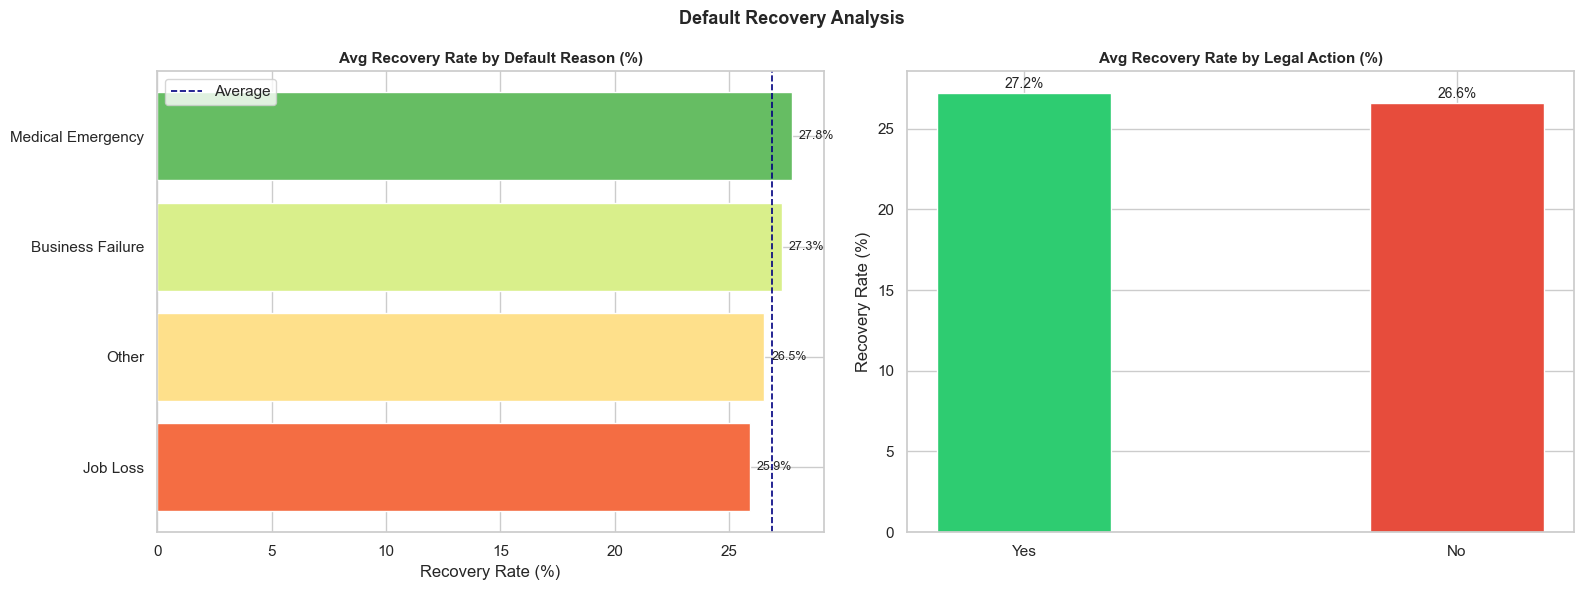


Recovery by Default Reason:
   Default_Reason  Count  Avg_Default_Amount  Avg_Recovery_Rate
         Job Loss   2160            52535.84              25.90
            Other   2293            53345.43              26.54
 Business Failure   2285            53359.29              27.31
Medical Emergency   2262            52645.14              27.76

Recovery by Legal Action:
Legal_Action  Count  Avg_Recovery_Rate
         Yes   4450              27.19
          No   4550              26.60


In [29]:
defs['Recovery_Rate'] = np.where(
    defs['Default_Amount'] > 0,
    (defs['Recovery_Amount'] / defs['Default_Amount'] * 100).clip(0, 100),
    0
)

rec_reason = defs.groupby('Default_Reason').agg(
    Count=('Default_ID', 'count'),
    Avg_Default_Amount=('Default_Amount', 'mean'),
    Avg_Recovery_Rate=('Recovery_Rate', 'mean')
).sort_values('Avg_Recovery_Rate', ascending=True).reset_index()

rec_legal = defs.groupby('Legal_Action').agg(
    Count=('Default_ID', 'count'),
    Avg_Recovery_Rate=('Recovery_Rate', 'mean')
).sort_values('Avg_Recovery_Rate', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By Default Reason
colors_r = sns.color_palette('RdYlGn', len(rec_reason))
axes[0].barh(rec_reason['Default_Reason'], rec_reason['Avg_Recovery_Rate'],
             color=colors_r, edgecolor='white')
axes[0].axvline(rec_reason['Avg_Recovery_Rate'].mean(), color='navy',
                linestyle='--', linewidth=1.2, label='Average')
axes[0].set_title('Avg Recovery Rate by Default Reason (%)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Recovery Rate (%)')
axes[0].legend()
for i, v in enumerate(rec_reason['Avg_Recovery_Rate']):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# By Legal Action
colors_l = ['#2ecc71' if l == 'Yes' else '#e74c3c' for l in rec_legal['Legal_Action']]
axes[1].bar(rec_legal['Legal_Action'], rec_legal['Avg_Recovery_Rate'],
            color=colors_l, edgecolor='white', width=0.4)
axes[1].set_title('Avg Recovery Rate by Legal Action (%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Recovery Rate (%)')
for i, v in enumerate(rec_legal['Avg_Recovery_Rate']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Default Recovery Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRecovery by Default Reason:')
print(rec_reason.to_string(index=False))
print('\nRecovery by Legal Action:')
print(rec_legal.to_string(index=False))

## 7.3 Recovery Rates Across Regions

Recovery Summary by Region:
   Region  Count  Total_Defaulted  Total_Recovered  Avg_Recovery_Rate  Overall_Recovery_%
  Central   1158         60166820         14279370              26.24               23.73
     East   1200         64656315         14484667              24.75               22.40
    North   1169         62378265         15563080              27.42               24.95
Northeast   1155         59756404         14270424              26.86               23.88
    South   1161         60965366         15766509              28.10               25.86
     West   1171         64012891         14926765              26.12               23.32


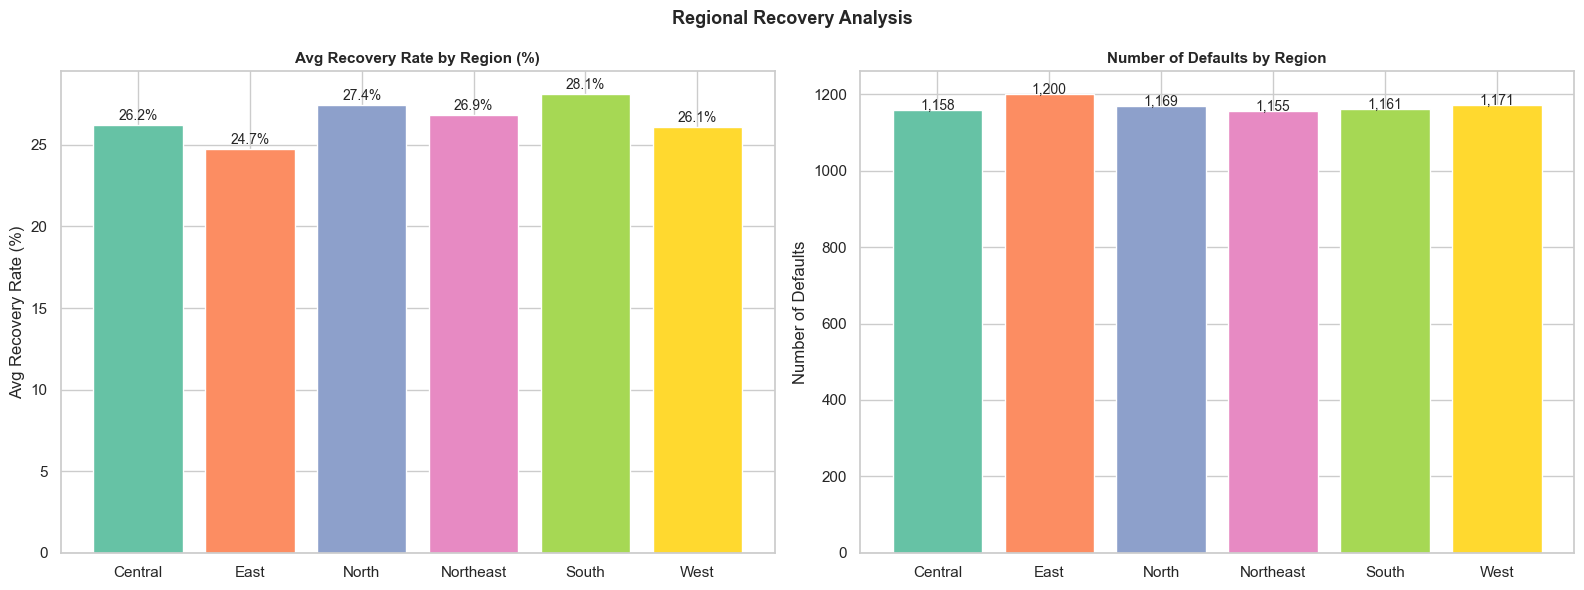

In [30]:
defs_region = defs.merge(cust[['Customer_ID', 'Region']], on='Customer_ID', how='left')
rec_reg = defs_region.groupby('Region').agg(
    Count=('Default_ID', 'count'),
    Total_Defaulted=('Default_Amount', 'sum'),
    Total_Recovered=('Recovery_Amount', 'sum'),
    Avg_Recovery_Rate=('Recovery_Rate', 'mean')
).reset_index()
rec_reg['Overall_Recovery_%'] = (
    rec_reg['Total_Recovered'] / rec_reg['Total_Defaulted'] * 100
).round(2)

print('Recovery Summary by Region:')
print(rec_reg.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette('Set2', len(rec_reg))

axes[0].bar(rec_reg['Region'], rec_reg['Avg_Recovery_Rate'], color=colors, edgecolor='white')
axes[0].set_title('Avg Recovery Rate by Region (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Avg Recovery Rate (%)')
for i, v in enumerate(rec_reg['Avg_Recovery_Rate']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

axes[1].bar(rec_reg['Region'], rec_reg['Count'], color=colors, edgecolor='white')
axes[1].set_title('Number of Defaults by Region', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Defaults')
for i, v in enumerate(rec_reg['Count']):
    axes[1].text(i, v + 1, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('Regional Recovery Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 💳 Task 8: EMI Analysis

> **Objectives**
> - Analyze the relationship between EMI amounts and default probabilities
> - Identify EMI thresholds where defaults are most likely
> - Compare EMI trends across loan types (Collateral)

---
## 8.1 EMI Distribution by Default Status

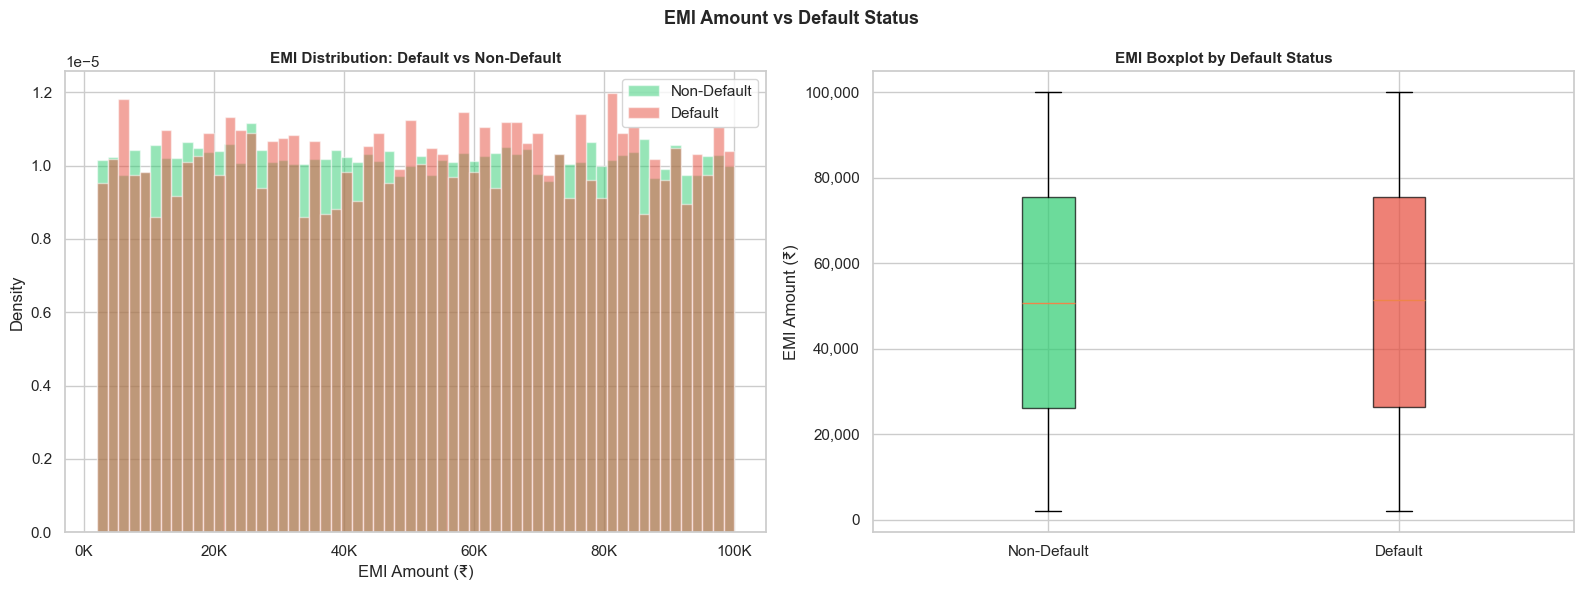

EMI Statistics by Default Status (0=Non-Default, 1=Default):
                count     mean      std     min      25%      50%      75%       max
Default_Flag                                                                        
0            81461.00 50849.61 28277.52 2001.00 26210.00 50779.00 75420.00  99999.00
1             8539.00 51108.56 28244.19 2007.00 26408.50 51412.00 75539.50 100000.00


In [31]:
emi_df = loan[['Loan_ID', 'EMI_Amount', 'Default_Flag',
               'Loan_Amount', 'Interest_Rate', 'Loan_Status',
               'Collateral_Details']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for flag, label, color in [(0, 'Non-Default', '#2ecc71'), (1, 'Default', '#e74c3c')]:
    subset = emi_df[emi_df['Default_Flag'] == flag]['EMI_Amount']
    axes[0].hist(subset, bins=60, color=color, label=label, alpha=0.5,
                 edgecolor='white', density=True)
axes[0].set_title('EMI Distribution: Default vs Non-Default', fontsize=11, fontweight='bold')
axes[0].set_xlabel('EMI Amount (₹)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

groups = [emi_df[emi_df['Default_Flag'] == f]['EMI_Amount'].dropna().values for f in [0, 1]]
bp = axes[1].boxplot(groups, patch_artist=True, labels=['Non-Default', 'Default'],
                     notch=False, showfliers=False)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('EMI Boxplot by Default Status', fontsize=11, fontweight='bold')
axes[1].set_ylabel('EMI Amount (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('EMI Amount vs Default Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('EMI Statistics by Default Status (0=Non-Default, 1=Default):')
print(emi_df.groupby('Default_Flag')['EMI_Amount'].describe().round(2).to_string())

## 8.2 EMI Threshold Analysis — Where Are Defaults Most Common?

Default Rate by EMI Bin:
            EMI_Bin  Total_Loans  Defaults  Avg_EMI  Default_Rate_%
  (1903.0, 11801.0]         8941       833  6906.34            9.32
 (11801.0, 21601.0]         9138       853 16712.57            9.33
 (21601.0, 31401.0]         9203       891 26464.34            9.68
 (31401.0, 41201.0]         8932       802 36312.17            8.98
 (41201.0, 51000.0]         8926       854 46084.81            9.57
 (51000.0, 60800.0]         8941       862 55909.65            9.64
 (60800.0, 70600.0]         9106       897 65671.93            9.85
 (70600.0, 80400.0]         8900       827 75527.65            9.29
 (80400.0, 90200.0]         9002       870 85248.45            9.66
(90200.0, 100000.0]         8911       850 95103.04            9.54


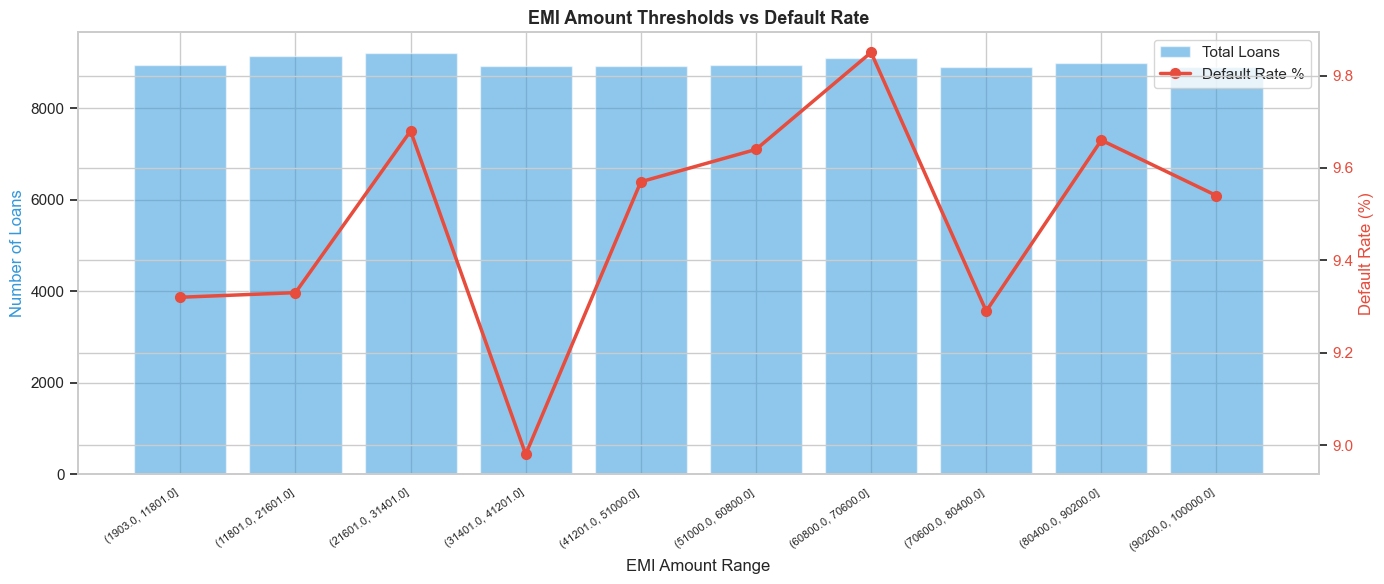

In [32]:
emi_df['EMI_Bin'] = pd.cut(emi_df['EMI_Amount'], bins=10, precision=0)
emi_thresh = emi_df.groupby('EMI_Bin', observed=False).agg(
    Total_Loans=('Loan_ID', 'count'),
    Defaults=('Default_Flag', 'sum'),
    Default_Rate=('Default_Flag', 'mean'),
    Avg_EMI=('EMI_Amount', 'mean')
).reset_index()
emi_thresh['Default_Rate_%'] = (emi_thresh['Default_Rate'] * 100).round(2)

print('Default Rate by EMI Bin:')
print(emi_thresh[['EMI_Bin', 'Total_Loans', 'Defaults', 'Avg_EMI', 'Default_Rate_%']].to_string(index=False))

fig, ax1 = plt.subplots(figsize=(14, 6))
x = range(len(emi_thresh))
ax1.bar(x, emi_thresh['Total_Loans'], color='#3498db', alpha=0.55, edgecolor='white', label='Total Loans')
ax1.set_xlabel('EMI Amount Range')
ax1.set_ylabel('Number of Loans', color='#3498db')
ax1.set_xticks(x)
ax1.set_xticklabels([str(b) for b in emi_thresh['EMI_Bin']], rotation=35, ha='right', fontsize=8)

ax2 = ax1.twinx()
ax2.plot(x, emi_thresh['Default_Rate_%'], color='#e74c3c', marker='o',
         linewidth=2.5, markersize=7, label='Default Rate %', zorder=5)
ax2.set_ylabel('Default Rate (%)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_title('EMI Amount Thresholds vs Default Rate', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

## 8.3 EMI Trends Across Loan (Collateral) Types

EMI Analysis by Collateral Type:
Collateral_Details  Count  Avg_EMI  Median_EMI  Default_Rate_%
          Property  29921 50995.04    50747.00            9.57
              None  30194 50831.51    51008.00            9.45
           Vehicle  29885 50796.30    50814.00            9.45


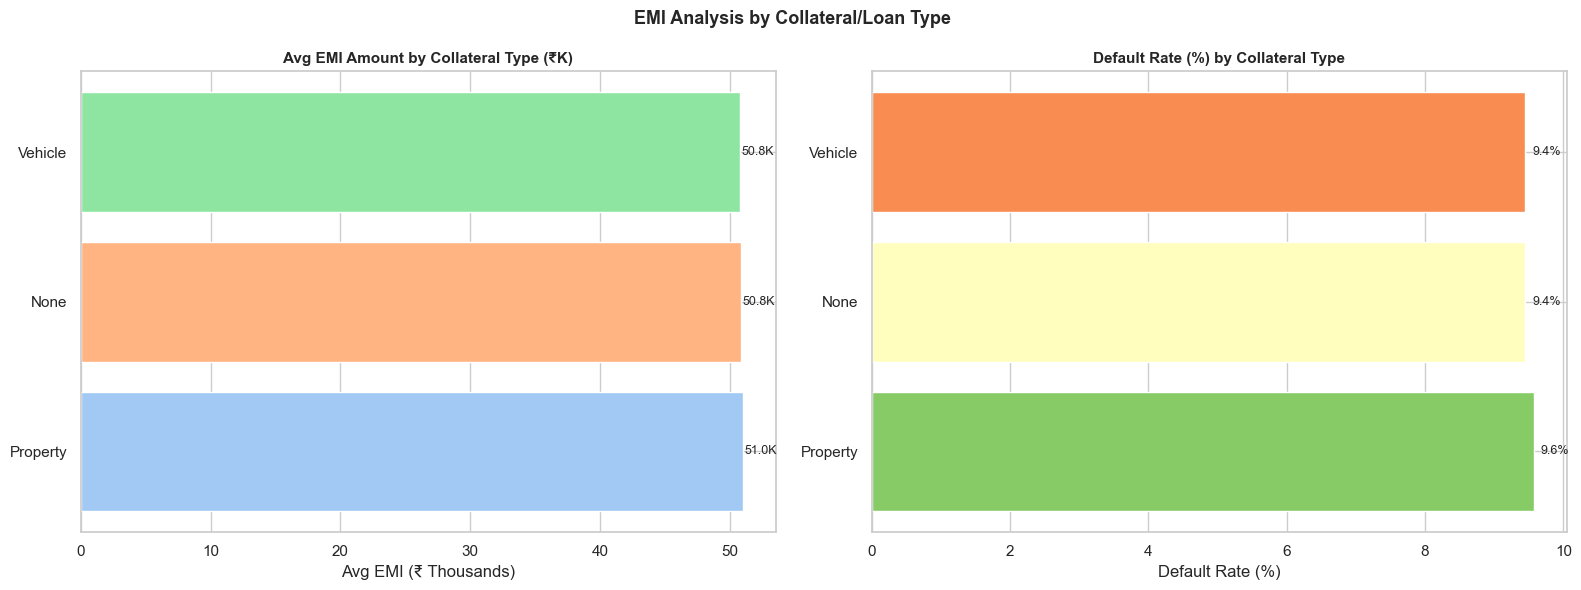

In [33]:
emi_coll = emi_df.groupby('Collateral_Details').agg(
    Count=('Loan_ID', 'count'),
    Avg_EMI=('EMI_Amount', 'mean'),
    Median_EMI=('EMI_Amount', 'median'),
    Default_Rate=('Default_Flag', 'mean')
).reset_index().sort_values('Avg_EMI', ascending=False)
emi_coll['Default_Rate_%'] = (emi_coll['Default_Rate'] * 100).round(2)

print('EMI Analysis by Collateral Type:')
print(emi_coll[['Collateral_Details', 'Count', 'Avg_EMI', 'Median_EMI', 'Default_Rate_%']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_c = sns.color_palette('pastel', len(emi_coll))

axes[0].barh(emi_coll['Collateral_Details'], emi_coll['Avg_EMI'] / 1e3,
             color=colors_c, edgecolor='white')
axes[0].set_title('Avg EMI Amount by Collateral Type (₹K)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Avg EMI (₹ Thousands)')
for i, v in enumerate(emi_coll['Avg_EMI'] / 1e3):
    axes[0].text(v + 0.1, i, f'{v:.1f}K', va='center', fontsize=9)

axes[1].barh(emi_coll['Collateral_Details'], emi_coll['Default_Rate_%'],
             color=sns.color_palette('RdYlGn_r', len(emi_coll)), edgecolor='white')
axes[1].set_title('Default Rate (%) by Collateral Type', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Default Rate (%)')
for i, v in enumerate(emi_coll['Default_Rate_%']):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('EMI Analysis by Collateral/Loan Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 📋 Task 9: Loan Application Insights

> **Objectives**
> - Calculate approval and rejection rates for loan applications
> - Identify the most common reasons for loan rejection
> - Compare application processing fees between approved and rejected applications

---
## 9.1 Approval and Rejection Rates

Application Status Summary:
  Approved       :   70,000  (84.8%)
  Rejected       :   12,600  (15.2%)


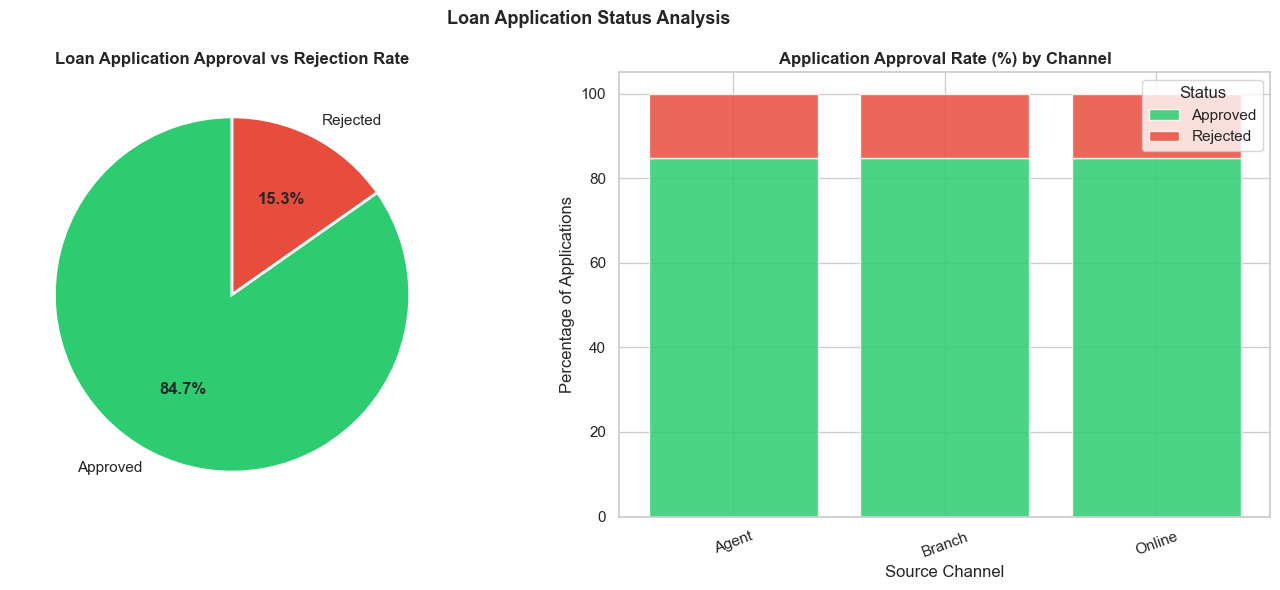

In [34]:
status_counts = apps['Approval_Status'].value_counts()
status_pct    = apps['Approval_Status'].value_counts(normalize=True).mul(100).round(2)

print('Application Status Summary:')
for s in status_counts.index:
    print(f'  {s:15s}: {status_counts[s]:>8,}  ({status_pct[s]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pie_colors = ['#2ecc71' if s == 'Approved' else '#e74c3c' for s in status_counts.index]
wedges, texts, autotexts = axes[0].pie(
    status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
    colors=pie_colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[0].set_title('Loan Application Approval vs Rejection Rate', fontsize=12, fontweight='bold')

channel_app = apps.groupby(['Source_Channel', 'Approval_Status']).size().unstack(fill_value=0)
channel_pct = channel_app.div(channel_app.sum(axis=1), axis=0).mul(100)
ch_colors = {'Approved': '#2ecc71', 'Rejected': '#e74c3c'}
bottom = np.zeros(len(channel_pct))
for status in channel_pct.columns:
    color = ch_colors.get(status, '#95a5a6')
    axes[1].bar(channel_pct.index, channel_pct[status], bottom=bottom,
                label=status, color=color, edgecolor='white', alpha=0.85)
    bottom += channel_pct[status].values
axes[1].set_title('Application Approval Rate (%) by Channel', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Source Channel')
axes[1].set_ylabel('Percentage of Applications')
axes[1].legend(title='Status')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Loan Application Status Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9.2 Most Common Loan Rejection Reasons

Total rejected applications: 12,600

Top 15 Rejection Reasons:
              Reason  Count  Pct_%
    Low Credit Score   4297  34.10
Incomplete Documents   4204  33.37
 Insufficient Income   4099  32.53


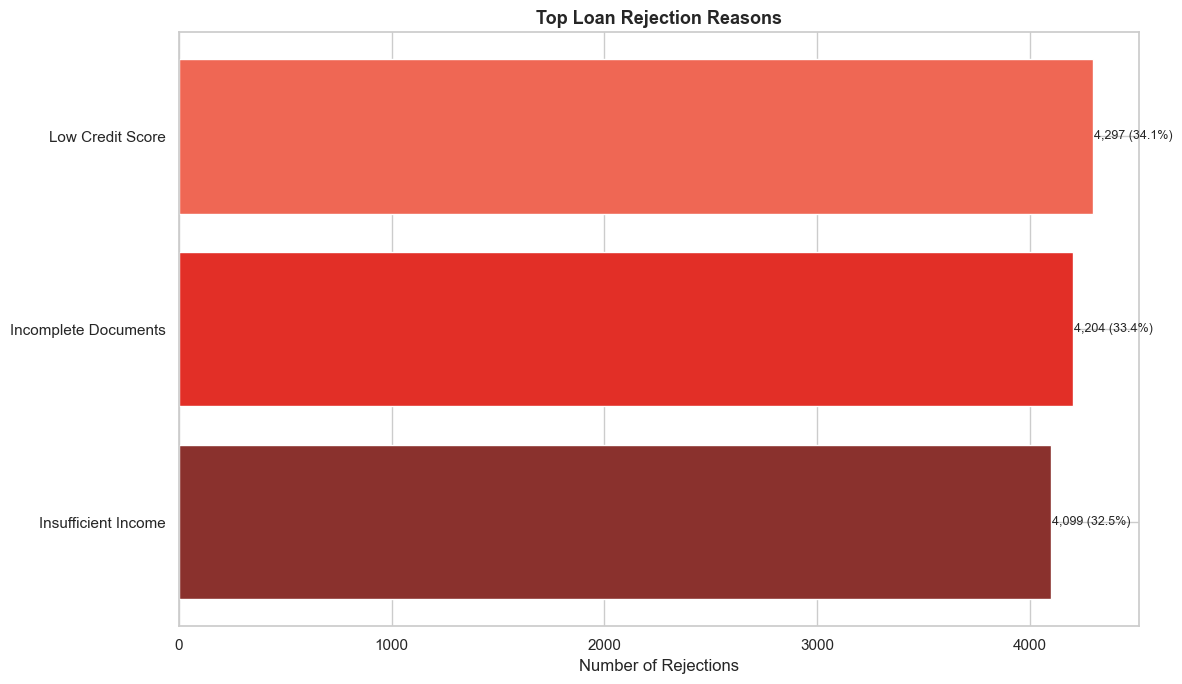

In [35]:
rejected = apps[apps['Approval_Status'] == 'Rejected'].copy()
rej_reasons = (rejected['Rejection_Reason']
               .replace({'N/A': np.nan, 'Unknown': np.nan})
               .dropna()
               .value_counts()
               .head(15)
               .reset_index())
rej_reasons.columns = ['Reason', 'Count']
rej_reasons['Pct_%'] = (rej_reasons['Count'] / len(rejected) * 100).round(2)

print(f'Total rejected applications: {len(rejected):,}')
print('\nTop 15 Rejection Reasons:')
print(rej_reasons.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 7))
grad_colors = sns.color_palette('Reds_d', len(rej_reasons))[::-1]
bars = ax.barh(rej_reasons['Reason'][::-1], rej_reasons['Count'][::-1],
               color=grad_colors, edgecolor='white')
ax.set_title('Top Loan Rejection Reasons', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Rejections')
rej_rev = rej_reasons.iloc[::-1].reset_index(drop=True)
for bar, (_, row) in zip(bars, rej_rev.iterrows()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{row["Count"]:,} ({row["Pct_%"]:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 9.3 Processing Fee — Approved vs Rejected

Processing Fee Statistics by Approval Status:
                 Count    Mean  Median     Std  Min    Max
Approval_Status                                           
Approved         70000 5252.40 5256.00 2741.57  500  10000
Rejected         12600 5255.14 5271.00 2721.01  500   9998

t-test: t=-0.1036,  p-value=9.1745e-01
No significant difference


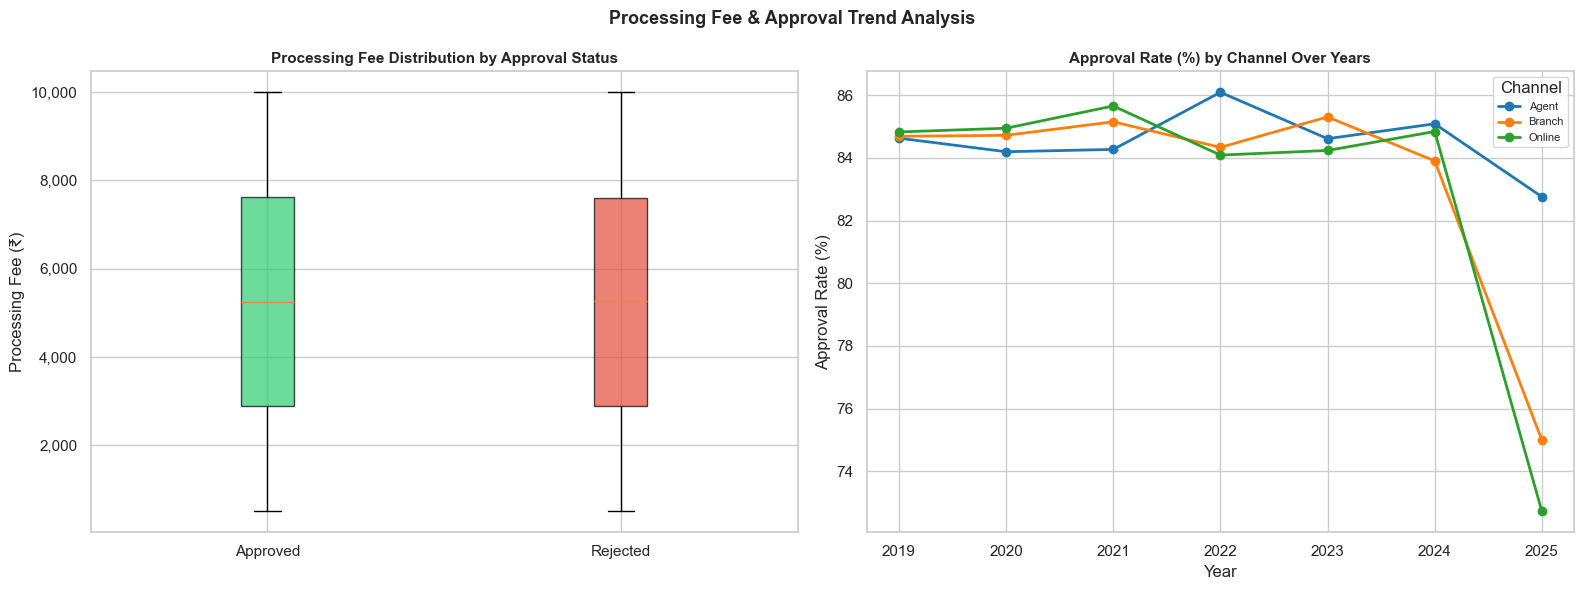

In [36]:
fee_stats = apps.groupby('Approval_Status')['Processing_Fee'].agg(
    Count='count', Mean='mean', Median='median', Std='std', Min='min', Max='max'
).round(2)
print('Processing Fee Statistics by Approval Status:')
print(fee_stats.to_string())

t_stat, p_val = stats.ttest_ind(
    apps[apps['Approval_Status'] == 'Approved']['Processing_Fee'].dropna(),
    apps[apps['Approval_Status'] == 'Rejected']['Processing_Fee'].dropna()
)
print(f'\nt-test: t={t_stat:.4f},  p-value={p_val:.4e}')
print('Statistically significant difference' if p_val < 0.05 else 'No significant difference')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
fee_groups = [apps[apps['Approval_Status'] == s]['Processing_Fee'].dropna().values
              for s in ['Approved', 'Rejected']]
bp = axes[0].boxplot(fee_groups, patch_artist=True, labels=['Approved', 'Rejected'],
                     notch=False, showfliers=False)
box_colors = ['#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Processing Fee Distribution by Approval Status', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Processing Fee (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Approval rate trend by year and channel
apps['App_Year'] = apps['Application_Date'].dt.year
yearly = apps.groupby(['App_Year', 'Source_Channel'])['Approval_Status'].apply(
    lambda x: (x == 'Approved').mean() * 100
).reset_index()
yearly.columns = ['Year', 'Source_Channel', 'Approval_Rate_%']
channel_palette = sns.color_palette('tab10', yearly['Source_Channel'].nunique())
for i, channel in enumerate(yearly['Source_Channel'].unique()):
    subset = yearly[yearly['Source_Channel'] == channel]
    axes[1].plot(subset['Year'], subset['Approval_Rate_%'], marker='o',
                 linewidth=2, label=channel, color=channel_palette[i])
axes[1].set_title('Approval Rate (%) by Channel Over Years', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Approval Rate (%)')
axes[1].legend(title='Channel', fontsize=8)

plt.suptitle('Processing Fee & Approval Trend Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# ✅ Summary of All 9 Tasks

| Task | Focus Area | Key Techniques Used |
|------|------------|---------------------|
| **1** | Data Quality & Preparation | IQR capping, missing value imputation, date parsing, deduplication |
| **2** | Descriptive Analysis | Histograms, bar charts, time-series line plots |
| **3** | Default Risk Analysis | Pearson correlation, heatmaps, branch-level merges |
| **4** | Branch & Regional Performance | Ranking tables, grouped bar charts, comparative plots |
| **5** | Customer Segmentation | pd.cut / pd.qcut, risk scoring, behavioural profiling |
| **6** | Advanced Statistical Analysis | Pearson + Spearman, p-values, comprehensive heatmaps |
| **7** | Transaction & Recovery Analysis | Time-series, recovery rate calculation, regional breakdown |
| **8** | EMI Analysis | EMI binning, dual-axis plots, collateral type comparison |
| **9** | Loan Application Insights | Stacked bars, t-test, rejection reason ranking |

> 🎯 **All 9 analysis tasks completed with full markdown documentation and visualisations.**
